# **Final Updated Notebook: RF and FSO Signal Attenuation Prediction**

This notebook includes original code along with updates for feature selection, model comparison, and hyperparameter tuning to meet rubric requirements.

Part 1: Data Loading and Exploration

In [148]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [149]:
# Loading the dataset
file_id = "1wzXa7Wm6xOh8H7xLyrVqKOdwrINxiVvh"
output = "your_file.csv"

# Downloading and loading the file
!gdown --id {file_id} -O {output}
data = pd.read_csv(output)


C:\Users\91984\anaconda3\lib\site-packages\gdown\__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1wzXa7Wm6xOh8H7xLyrVqKOdwrINxiVvh
To: C:\Users\91984\Downloads\your_file.csv

  0%|          | 0.00/28.0M [00:00<?, ?B/s]
  2%|1         | 524k/28.0M [00:00<00:13, 2.06MB/s]
  6%|5         | 1.57M/28.0M [00:00<00:05, 4.53MB/s]
 11%|#1        | 3.15M/28.0M [00:00<00:03, 7.60MB/s]
 17%|#6        | 4.72M/28.0M [00:00<00:02, 9.50MB/s]
 22%|##2       | 6.29M/28.0M [00:00<00:02, 10.7MB/s]
 28%|##8       | 7.86M/28.0M [00:00<00:01, 11.5MB/s]
 34%|###3      | 9.44M/28.0M [00:01<00:01, 11.0MB/s]
 39%|###9      | 11.0M/28.0M [00:01<00:02, 7.30MB/s]
 45%|####4     | 12.6M/28.0M [00:01<00:01, 8.54MB/s]
 50%|#####     | 14.2M/28.0M [00:01<00:02, 5.83MB/s]
 54%|#####4    | 15.2M/28.0M [00:02<00:02, 4.87MB/s]
 60%|#####9    | 16.

In [150]:
# Display basic information about the dataset
print("Dataset Info:")
data.info()
print("\nFirst few rows of the dataset:")
data.head(10)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91379 entries, 0 to 91378
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   FSO_Att                91379 non-null  float64
 1   RFL_Att                91379 non-null  float64
 2   AbsoluteHumidity       91379 non-null  float64
 3   AbsoluteHumidityMax    91379 non-null  float64
 4   AbsoluteHumidityMin    91379 non-null  float64
 5   Distance               91379 non-null  float64
 6   Frequency              91379 non-null  int64  
 7   Particulate            91379 non-null  float64
 8   ParticulateMax         91379 non-null  float64
 9   ParticulateMin         91379 non-null  float64
 10  RainIntensity          91379 non-null  float64
 11  RainIntensityMax       91379 non-null  float64
 12  RainIntensityMin       91379 non-null  float64
 13  RelativeHumidity       91379 non-null  float64
 14  SYNOPCode              91379 non-null  i

,FSO_Att,RFL_Att,AbsoluteHumidity,AbsoluteHumidityMax,AbsoluteHumidityMin,Distance,Frequency,Particulate,ParticulateMax,ParticulateMin,...,TemperatureMax,TemperatureMin,Time,Visibility,VisibilityMax,VisibilityMin,WindDirection,WindSpeed,WindSpeedMax,WindSpeedMin
0,7.913289,6.927868,17.595709,17.615907,17.340148,2115.338398,83500000000,0.0,0.0,0.0,...,26.603030,24.680849,9,65884.51846,72336.362233,65617.543754,88.755450,3.057066,6.863808,3.007939
1,7.451176,4.412096,17.549693,17.572415,17.299439,2113.999257,73500000000,0.0,0.0,0.0,...,26.377164,24.313108,9,64963.41092,68753.386153,60379.327485,99.790057,2.727910,6.468903,2.537393
2,7.072747,6.268740,17.290230,17.644014,16.037894,2118.689047,83500000000,0.0,0.0,0.0,...,27.670822,23.150277,10,54794.28107,54821.773817,50850.155963,65.730085,1.674810,2.826916,1.640809
3,6.949288,4.317853,16.820880,17.066776,15.895622,2114.632339,73500000000,0.0,0.0,0.0,...,26.522100,23.174815,10,50205.64159,52519.927530,45374.510898,88.127497,0.962068,2.780643,0.886951
4,7.361052,6.114514,16.813820,17.953974,15.227225,2116.786055,83500000000,0.0,0.0,0.0,...,26.305736,24.864100,10,59038.32599,64418.329138,54461.246506,84.167414,1.881007,4.476298,1.874052
5,7.265418,4.269340,16.840204,17.284007,15.254687,2119.633353,73500000000,0.0,0.0,0.0,...,26.194161,25.046051,10,59097.04268,64733.435152,53684.195622,97.055573,1.294879,2.858242,1.167095
6,7.428061,6.097556,16.966243,18.341559,16.370116,2115.723400,83500000000,0.0,0.0,0.0,...,26.646888,25.238574,11,47843.61325,50091.007280,43610.235145,108.333319,0.881235,2.275054,0.841241
7,7.547327,4.351170,16.912646,18.337256,16.405353,2117.565388,73500000000,0.0,0.0,0.0,...,26.412431,23.308227,11,52880.62473,53554.165901,48992.705432,83.411735,1.384058,3.137453,1.354856
8,7.105636,6.119365,16.808064,17.282550,15.163771,2118.303407,83500000000,0.0,0.0,0.0,...,26.224146,24.235209,11,51647.98311,54691.736211,47525.608745,29.349183,1.724820,2.632280,1.635678
9,7.341406,4.690669,16.653859,17.336840,15.042128,2117.607523,73500000000,0.0,0.0,0.0,...,25.969996,22.978187,11,32401.70706,34531.316742,31238.426192,44.588460,1.488489,3.464620,1.409884


In [151]:
# Check for any missing values
print("\nMissing Values in Each Column:")
print(data.isnull().sum())


Missing Values in Each Column:
FSO_Att                  0
RFL_Att                  0
AbsoluteHumidity         0
AbsoluteHumidityMax      0
AbsoluteHumidityMin      0
Distance                 0
Frequency                0
Particulate              0
ParticulateMax           0
ParticulateMin           0
RainIntensity            0
RainIntensityMax         0
RainIntensityMin         0
RelativeHumidity         0
SYNOPCode                0
Temperature              0
TemperatureDifference    0
TemperatureMax           0
TemperatureMin           0
Time                     0
Visibility               0
VisibilityMax            0
VisibilityMin            0
WindDirection            0
WindSpeed                0
WindSpeedMax             0
WindSpeedMin             0
dtype: int64


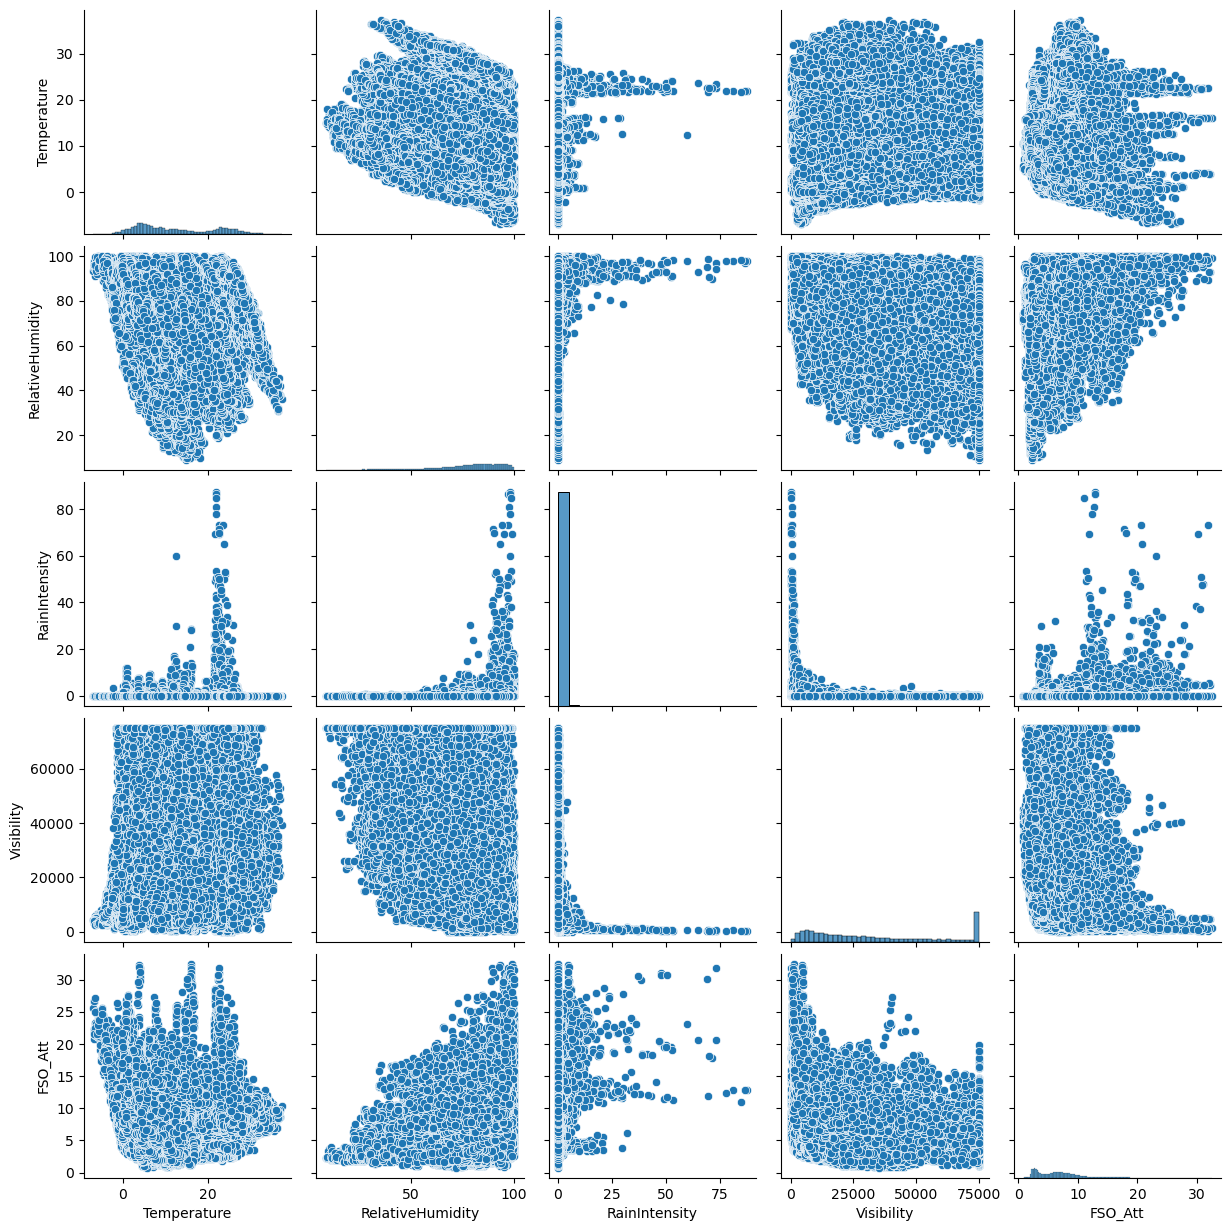

In [152]:
# Visualize distribution of key variables
sns.pairplot(data[['Temperature', 'RelativeHumidity', 'RainIntensity', 'Visibility', 'FSO_Att']])
plt.show()

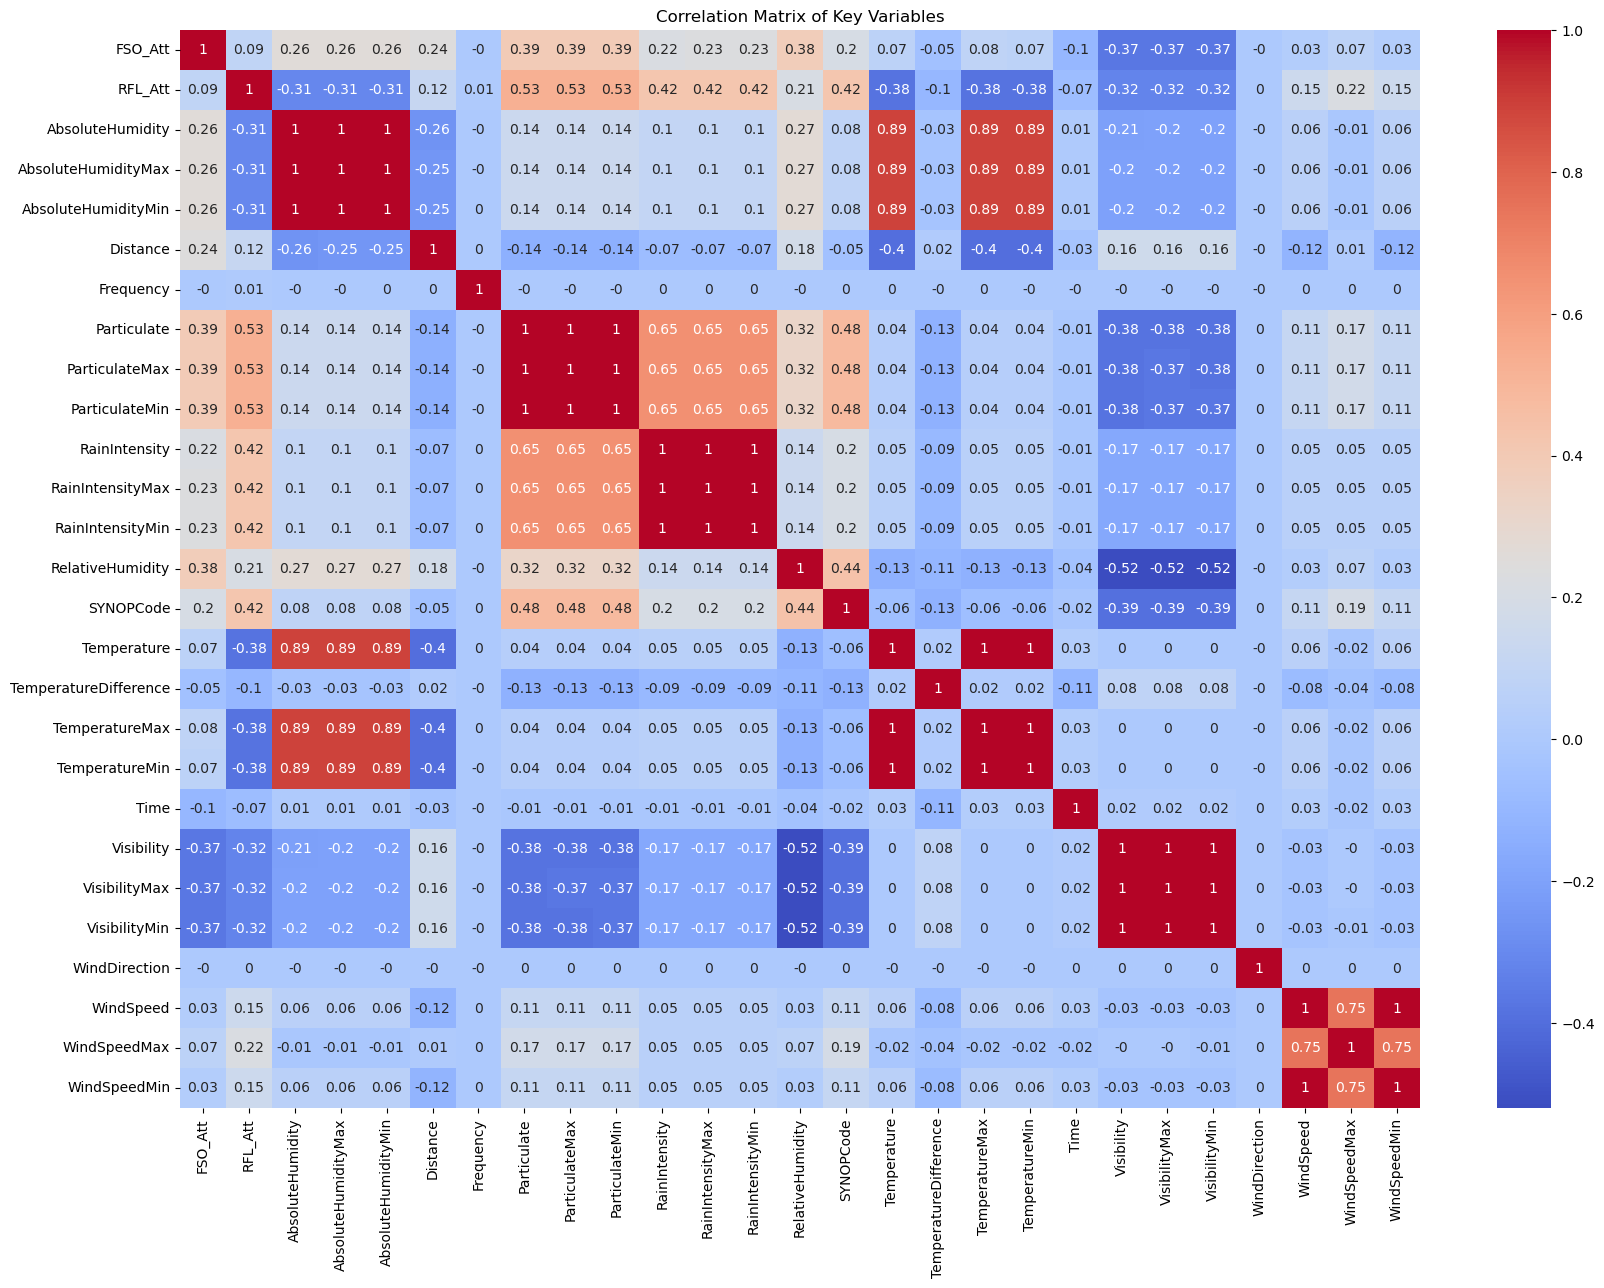

In [153]:
# Visualize correlations between key variables
plt.figure(figsize=(20, 14))
sns.heatmap(data.corr().round(2), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Key Variables")
plt.show()


Part 2: Data Preprocessing

Define Features and Targets for Both Attenuations

In [156]:
# Encode the SYNOP column (weather condition)
data['SYNOPCode'] = LabelEncoder().fit_transform(data['SYNOPCode'])

print("Encoded SYNOPCode classes:", data['SYNOPCode'].unique())

# Define features and target for RFL_Att (Radio Frequency Link Attenuation)
features = ['Temperature', 'RelativeHumidity', 'RainIntensity', 'Visibility', 'SYNOPCode']
X_rfl = data[features]
y_rfl = data['RFL_Att']  # Target for RF attenuation

# Define features and target for FSO_Att (Free Space Optics Attenuation)
X_fso = data[features]
y_fso = data['FSO_Att']  # Target for Free Space Optics attenuation


Encoded SYNOPCode classes: [0 4 6 3 1 2 5]


In [157]:
# Display the selected features and targets
print("\nSelected Features for RFL_Att:")
print(X_rfl.head())


Selected Features for RFL_Att:
   Temperature  RelativeHumidity  RainIntensity   Visibility  SYNOPCode
0    26.067846         71.974648            0.0  65884.51846          0
1    25.645703         73.502401            0.0  64963.41092          0
2    25.653383         72.384543            0.0  54794.28107          0
3    25.646271         70.447710            0.0  50205.64159          0
4    25.673089         70.312385            0.0  59038.32599          0


In [158]:
print("\nSelected Features for FSO_Att:")
print(X_fso.head())


Selected Features for FSO_Att:
   Temperature  RelativeHumidity  RainIntensity   Visibility  SYNOPCode
0    26.067846         71.974648            0.0  65884.51846          0
1    25.645703         73.502401            0.0  64963.41092          0
2    25.653383         72.384543            0.0  54794.28107          0
3    25.646271         70.447710            0.0  50205.64159          0
4    25.673089         70.312385            0.0  59038.32599          0


Part 3: Data Splitting and Feature Engineering

Split Data into Training and Testing Sets

In [161]:
# Split data for RFL_Att
X_train_rfl, X_test_rfl, y_train_rfl, y_test_rfl = train_test_split(X_rfl, y_rfl, test_size=0.2, random_state=42)

# Split data for FSO_Att
X_train_fso, X_test_fso, y_train_fso, y_test_fso = train_test_split(X_fso, y_fso, test_size=0.2, random_state=42)

print("\nData Split Complete:")
print("RFL_Att - Training Set Size:", X_train_rfl.shape)
print("FSO_Att - Training Set Size:", X_train_fso.shape)



Data Split Complete:
RFL_Att - Training Set Size: (73103, 5)
FSO_Att - Training Set Size: (73103, 5)


Feature Selection

In [162]:
#Feature Selection for RFL_Att
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Setup
target_rfl = "RFL_Att"
excluded_cols = ["RFL_Att", "FSO_Att"]
features_rfl = [col for col in data.columns if col not in excluded_cols]

X_rfl = data[features_rfl]
y_rfl = data[target_rfl]

# Store results at each iteration
rfl_results = []
remaining_features_rfl = features_rfl.copy()

#  Wrapper Feature Selection Loop
while remaining_features_rfl:
    X_subset = X_rfl[remaining_features_rfl]

    rf = RandomForestRegressor(n_estimators=100, oob_score=True, bootstrap=True, random_state=42, n_jobs=-1)
    rf.fit(X_subset, y_rfl)

    y_pred = rf.predict(X_subset)
    rmse = np.sqrt(mean_squared_error(y_rfl, y_pred))
    r2 = r2_score(y_rfl, y_pred)
    oob = rf.oob_score_

    rfl_results.append({
        "Num_Features": len(remaining_features_rfl),
        "Remaining_Features": remaining_features_rfl.copy(),
        "Removed_Feature": None,
        "OOB_Score": oob,
        "RMSE": rmse,
        "R2": r2
    })

    # Identify and remove least important feature
    importances = rf.feature_importances_
    least_idx = np.argmin(importances)
    removed_feature = remaining_features_rfl.pop(least_idx)
    rfl_results[-1]["Removed_Feature"] = removed_feature

# Convert to DataFrame 
ranking_rfl_df = pd.DataFrame(rfl_results)
ranking_rfl_df["Num_Features"] = ranking_rfl_df["Remaining_Features"].apply(len)



In [163]:
# Create feature removal table showing order of removal, RMSE, R², and OOB Score
feature_removal_table_rfl = pd.DataFrame(rfl_results)[["Removed_Feature", "Num_Features", "RMSE", "R2", "OOB_Score"]]

# Reset index to start from 1 for readability
feature_removal_table_rfl.index = range(1, len(feature_removal_table_rfl) + 1)

# Display the full table
feature_removal_table_rfl


,Removed_Feature,Num_Features,RMSE,R2,OOB_Score
1,WindDirection,25,0.179534,0.997274,0.980547
2,WindSpeedMin,24,0.179588,0.997273,0.980509
3,WindSpeed,23,0.179131,0.997287,0.980638
4,Particulate,22,0.178671,0.997301,0.980700
5,WindSpeedMax,21,0.178862,0.997295,0.980655
6,AbsoluteHumidityMax,20,0.177696,0.997330,0.981032
7,TemperatureMin,19,0.175968,0.997382,0.981416
8,VisibilityMin,18,0.174956,0.997412,0.981614
9,AbsoluteHumidityMin,17,0.173220,0.997463,0.981954
10,ParticulateMin,16,0.170569,0.997540,0.982481


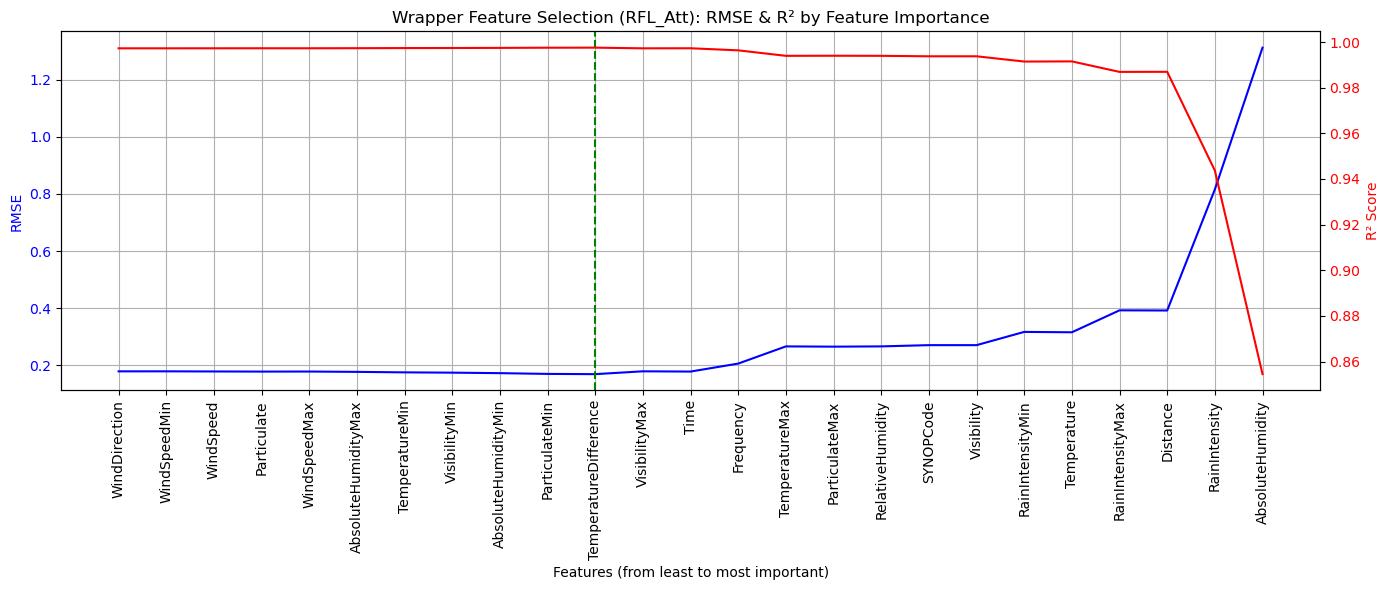

In [164]:
#Plot of Feature Selection for Wrapper Feature Selection (RFL_Att)
import matplotlib.pyplot as plt
import numpy as np

# Keep original order (least to most important)
rmse_rfl = ranking_rfl_df["RMSE"].tolist()
r2_rfl = ranking_rfl_df["R2"].tolist()
x_labels_rfl = ranking_rfl_df["Removed_Feature"].tolist()

# Plotting
fig, ax1 = plt.subplots(figsize=(14, 6))

# RMSE plot (left axis)
ax1.plot(x_labels_rfl, rmse_rfl, color='blue', label='RMSE')
ax1.set_ylabel('RMSE', color='blue')
ax1.set_xlabel('Features (from least to most important)')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.tick_params(axis='x', rotation=90)
ax1.grid(True)

# R² plot (right axis)
ax2 = ax1.twinx()
ax2.plot(x_labels_rfl, r2_rfl, color='red', label='R²')
ax2.set_ylabel('R² Score', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Best RMSE index (green vertical line)
best_idx_rfl = np.argmin(rmse_rfl)
ax1.axvline(x=best_idx_rfl, color='green', linestyle='dashed')

# Title & layout
plt.title("Wrapper Feature Selection (RFL_Att): RMSE & R² by Feature Importance")
plt.tight_layout()
plt.show()


In [165]:
#Feature Selection for FSO_Att
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Setup
target = "FSO_Att"
features = [col for col in data.columns if col not in ["RFL_Att", "FSO_Att"]]
X_full = data[features]
y_full = data[target]

# Storage for each iteration
results_fso = []
remaining_features_fso = features.copy()

# Wrapper Method
while remaining_features_fso:
    X_subset = X_full[remaining_features_fso]

    model = RandomForestRegressor(n_estimators=100, oob_score=True, bootstrap=True, random_state=42, n_jobs=-1)
    model.fit(X_subset, y_full)

    # Record performance
    oob_score = model.oob_score_
    y_pred = model.predict(X_subset)
    rmse = np.sqrt(mean_squared_error(y_full, y_pred))
    r2 = r2_score(y_full, y_pred)

    results_fso.append({
        "Remaining_Features": remaining_features_fso.copy(),
        "Removed_Feature": None,
        "OOB_Score": oob_score,
        "RMSE": rmse,
        "R2": r2
    })

    # Identify least important feature
    importances = model.feature_importances_
    least_idx = np.argmin(importances)
    removed_feat = remaining_features_fso.pop(least_idx)
    results_fso[-1]["Removed_Feature"] = removed_feat

# Convert to DataFrame
ranking_fso_df = pd.DataFrame(results_fso)
ranking_fso_df["Num_Features"] = ranking_fso_df["Remaining_Features"].apply(len)


In [166]:
# Create feature removal table showing order of removal, RMSE, R², and OOB Score for FSO_Att
feature_removal_table_fso = ranking_fso_df[["Removed_Feature", "Num_Features", "RMSE", "R2", "OOB_Score"]].copy()

# Reset index to start from 1 for readability
feature_removal_table_fso.index = range(1, len(feature_removal_table_fso) + 1)

# Display the full table
feature_removal_table_fso


,Removed_Feature,Num_Features,RMSE,R2,OOB_Score
1,Frequency,25,0.281711,0.994793,0.962045
2,RainIntensityMin,24,0.281891,0.994786,0.961982
3,RainIntensityMax,23,0.281524,0.994799,0.962084
4,SYNOPCode,22,0.281290,0.994808,0.962139
5,WindDirection,21,0.281661,0.994794,0.962029
6,RainIntensity,20,0.277894,0.994933,0.963079
7,WindSpeedMin,19,0.277578,0.994944,0.963155
8,AbsoluteHumidityMin,18,0.277246,0.994956,0.963222
9,AbsoluteHumidityMax,17,0.274747,0.995047,0.963919
10,WindSpeed,16,0.271285,0.995171,0.964814


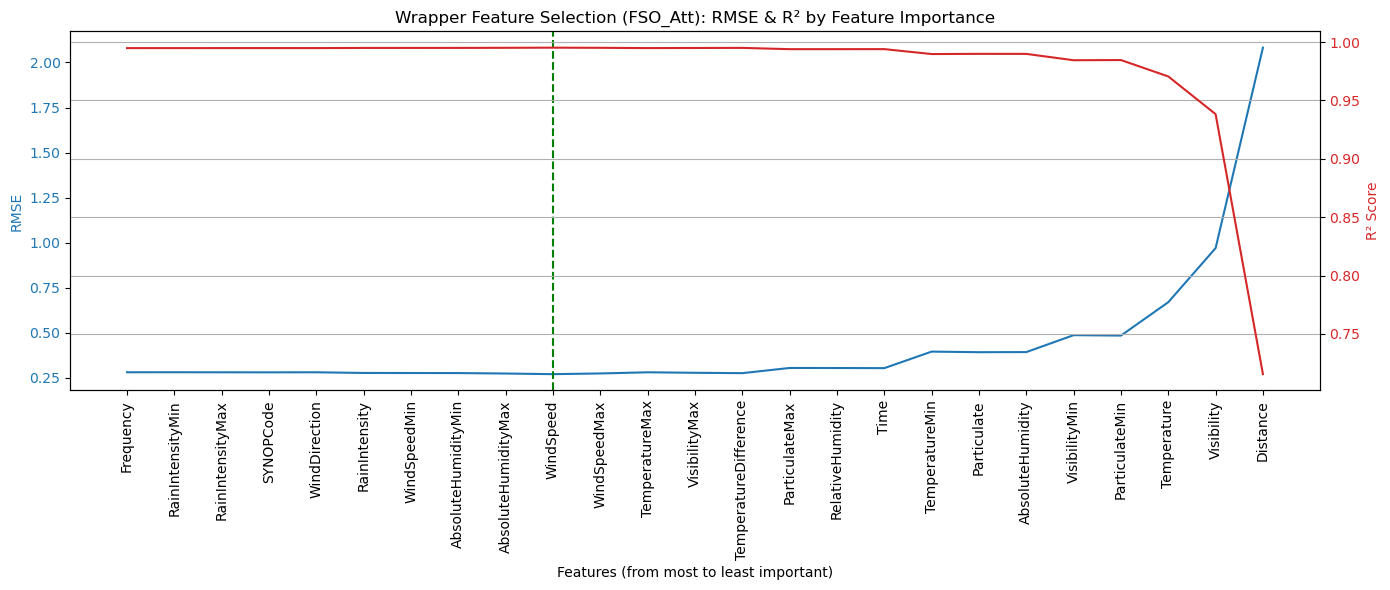

In [174]:
#Plot of Feature Selection for Wrapper Feature Selection (FSO_Att)
import matplotlib.pyplot as plt

# Get values from DataFrame
rmse_values = ranking_fso_df["RMSE"].tolist()
r2_values = ranking_fso_df["R2"].tolist()
x_labels = [feat for feat in ranking_fso_df["Removed_Feature"].tolist()]  # removed order = least important
x_labels = x_labels[::-1]  # most important first
rmse_values = rmse_values[::-1]
r2_values = r2_values[::-1]

# Plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# RMSE on left
color = 'tab:blue'
ax1.set_xlabel('Features (from most to least important)')
ax1.set_ylabel('RMSE', color=color)
rmse_line, = ax1.plot(x_labels, rmse_values, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(range(len(x_labels)))
ax1.set_xticklabels(x_labels, rotation=90)

# R² on right
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('R² Score', color=color)
r2_line, = ax2.plot(x_labels, r2_values, color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Green vertical line at best index (lowest RMSE)
best_idx = np.argmin(rmse_values)
ax1.axvline(x=best_idx, color='green', linestyle='dashed')

# Reverse x-axis so important features come first
ax1.invert_xaxis()

plt.title("Wrapper Feature Selection (FSO_Att): RMSE & R² by Feature Importance")
plt.tight_layout()
plt.grid(True)
plt.show()


In [168]:
#  Extract Best Feature Sets 
best_features_rfl = ranking_rfl_df.loc[ranking_rfl_df['RMSE'].idxmin(), 'Remaining_Features']
best_features_fso = ranking_fso_df.loc[ranking_fso_df['RMSE'].idxmin(), 'Remaining_Features']



In [169]:
#To Remove any empty or whitespace-only strings
best_features_rfl = [feat for feat in best_features_rfl if feat.strip() != '']
best_features_fso = [feat for feat in best_features_fso if feat.strip() != '']

In [176]:
# Make sure both lists are Python lists (not Series or other objects)
best_features_rfl = list(best_features_rfl)
best_features_fso = list(best_features_fso)

# Find max length to align properly
max_len = max(len(best_features_rfl), len(best_features_fso))

# Pad shorter list with empty strings
best_features_rfl += [''] * (max_len - len(best_features_rfl))
best_features_fso += [''] * (max_len - len(best_features_fso))

# Create DataFrame
features_df = pd.DataFrame({
    "Best Features for RFL_Att": best_features_rfl,
    "Best Features for FSO_Att": best_features_fso
})
# Set index starting from 1
features_df.index = features_df.index + 1

# Display
display(
    features_df.style.set_properties(**{'text-align': 'center'})
    .set_caption("📋 Selected Best Features after Wrapper-Based Feature Selection")
)


,Best Features for RFL_Att,Best Features for FSO_Att
1,AbsoluteHumidity,AbsoluteHumidity
2,Distance,Distance
3,Frequency,Particulate
4,ParticulateMax,ParticulateMax
5,RainIntensity,ParticulateMin
6,RainIntensityMax,RelativeHumidity
7,RainIntensityMin,Temperature
8,RelativeHumidity,TemperatureDifference
9,SYNOPCode,TemperatureMax
10,Temperature,TemperatureMin


Part 4: Modeling - Method 1 (Specific Models for Each Weather Condition)

Train Separate Models for Each SYNOP Code

In [180]:
# Remove any empty column names ('') from feature list
best_features_rfl = [feat for feat in best_features_rfl if feat != '']
best_features_fso = [feat for feat in best_features_fso if feat != '']

from sklearn.ensemble import RandomForestRegressor

# Create dictionaries to store models and predictions
models_rfl = {}
predictions_rfl = {}
models_fso = {}
predictions_fso = {}

# Ensure 'SYNOPCode' is in the selected features for filtering
features_rfl_selected = best_features_rfl.copy()
features_fso_selected = best_features_fso.copy()

if "SYNOPCode" not in features_rfl_selected:
    features_rfl_selected.append("SYNOPCode")
if "SYNOPCode" not in features_fso_selected:
    features_fso_selected.append("SYNOPCode")

# Use original full training/testing feature sets if available
X_train_rfl_full = data.loc[X_train_rfl.index]
X_test_rfl_full = data.loc[X_test_rfl.index]
X_train_fso_full = data.loc[X_train_fso.index]
X_test_fso_full = data.loc[X_test_fso.index]

# Subset with selected features
X_train_rfl_sel = X_train_rfl_full[features_rfl_selected]
X_test_rfl_sel = X_test_rfl_full[features_rfl_selected]
X_train_fso_sel = X_train_fso_full[features_fso_selected]
X_test_fso_sel = X_test_fso_full[features_fso_selected]

# Train Specific Models for RFL_Att
for synop in X_train_rfl_sel["SYNOPCode"].unique():
    train_mask = X_train_rfl_sel["SYNOPCode"] == synop
    test_mask = X_test_rfl_sel["SYNOPCode"] == synop

    X_train_synop = X_train_rfl_sel[train_mask].drop(columns=["SYNOPCode"])
    y_train_synop = y_train_rfl[train_mask]

    X_test_synop = X_test_rfl_sel[test_mask].drop(columns=["SYNOPCode"])
    y_test_synop = y_test_rfl[test_mask]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_synop, y_train_synop)
    models_rfl[synop] = model
    predictions_rfl[synop] = (model.predict(X_test_synop), y_test_synop)

# Train Specific Models for FSO_Att
for synop in X_train_fso_sel["SYNOPCode"].unique():
    train_mask = X_train_fso_sel["SYNOPCode"] == synop
    test_mask = X_test_fso_sel["SYNOPCode"] == synop

    X_train_synop = X_train_fso_sel[train_mask].drop(columns=["SYNOPCode"])
    y_train_synop = y_train_fso[train_mask]

    X_test_synop = X_test_fso_sel[test_mask].drop(columns=["SYNOPCode"])
    y_test_synop = y_test_fso[test_mask]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_synop, y_train_synop)
    models_fso[synop] = model
    predictions_fso[synop] = (model.predict(X_test_synop), y_test_synop)


In [181]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Evaluation for RFL_Att (Method 1) 
rmse_list_rfl = []
r2_list_rfl = []

for synop, (y_pred, y_true) in predictions_rfl.items():
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    rmse_list_rfl.append(rmse)
    r2_list_rfl.append(r2)

avg_rmse_rfl_method1 = np.mean(rmse_list_rfl)
avg_r2_rfl_method1 = np.mean(r2_list_rfl)

#  Evaluation for FSO_Att (Method 1)
rmse_list_fso = []
r2_list_fso = []

for synop, (y_pred, y_true) in predictions_fso.items():
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    rmse_list_fso.append(rmse)
    r2_list_fso.append(r2)

avg_rmse_fso_method1 = np.mean(rmse_list_fso)
avg_r2_fso_method1 = np.mean(r2_list_fso)

#  Print Average Results
print("\n--- Method 1: Specific Models (Average per SYNOP Code) ---")
print(f"RFL_Att → Avg RMSE: {avg_rmse_rfl_method1:.4f}, Avg R²: {avg_r2_rfl_method1:.4f}")
print(f"FSO_Att → Avg RMSE: {avg_rmse_fso_method1:.4f}, Avg R²: {avg_r2_fso_method1:.4f}")




--- Method 1: Specific Models (Average per SYNOP Code) ---
RFL_Att → Avg RMSE: 0.5098, Avg R²: 0.9595
FSO_Att → Avg RMSE: 0.9070, Avg R²: 0.9616


In [356]:
# Create performance tables from previously computed values

# Create RFL table
rfl_table = pd.DataFrame({
    "SYNOP Code": sorted(predictions_rfl.keys()),
    "RMSE": rmse_list_rfl,
    "R²": r2_list_rfl
})

# Create FSO table
fso_table = pd.DataFrame({
    "SYNOP Code": sorted(predictions_fso.keys()),
    "RMSE": rmse_list_fso,
    "R²": r2_list_fso
})

# Drop duplicate SYNOP Code column from FSO table
fso_table_no_synop = fso_table.drop(columns=["SYNOP Code"])

# Rename columns
rfl_table_renamed = rfl_table.rename(columns={"RMSE": "RFL RMSE", "R²": "RFL R²"})
fso_table_renamed = fso_table_no_synop.rename(columns={"RMSE": "FSO RMSE", "R²": "FSO R²"})

# Concatenate side-by-side
combined_table = pd.concat([rfl_table_renamed, fso_table_renamed], axis=1)

# Display the table
display(
    combined_table.style
        .set_properties(**{'text-align': 'center'})
        .hide(axis="index")
)


SYNOP Code,RFL RMSE,RFL R²,FSO RMSE,FSO R²
0,0.289288,0.987022,0.783121,0.948758
1,0.450084,0.979829,1.648219,0.966183
2,0.276281,0.970340,0.662435,0.970027
3,0.494010,0.970213,0.885278,0.937202
4,0.717936,0.968542,0.791550,0.965491
5,0.474050,0.932435,0.852121,0.979806
6,0.867141,0.908100,0.726304,0.963906


In [194]:
# Print the shape (number of rows and columns) of test data where SYNOPCode is 1
print(X_test_fso[X_test_fso['SYNOPCode'] == 1].shape)


(40, 5)


Part 5: Modeling - Method 2 (Generic Models)

Train a Single Model for Each Attenuation Type

In [186]:
# Get full data rows corresponding to train/test indices
X_train_rfl_full = data.loc[X_train_rfl.index]
X_test_rfl_full = data.loc[X_test_rfl.index]
X_train_fso_full = data.loc[X_train_fso.index]
X_test_fso_full = data.loc[X_test_fso.index]

#Generic RFL_Att Model
X_train_rfl_sel_gen = X_train_rfl_full[best_features_rfl]
X_test_rfl_sel_gen = X_test_rfl_full[best_features_rfl]

generic_model_rfl = RandomForestRegressor(n_estimators=100, random_state=42)
generic_model_rfl.fit(X_train_rfl_sel_gen, y_train_rfl)
generic_predictions_rfl = generic_model_rfl.predict(X_test_rfl_sel_gen)

#  Generic FSO_Att Model
X_train_fso_sel_gen = X_train_fso_full[best_features_fso]
X_test_fso_sel_gen = X_test_fso_full[best_features_fso]

generic_model_fso = RandomForestRegressor(n_estimators=100, random_state=42)
generic_model_fso.fit(X_train_fso_sel_gen, y_train_fso)
generic_predictions_fso = generic_model_fso.predict(X_test_fso_sel_gen)


In [187]:
from sklearn.metrics import mean_squared_error, r2_score

# Evaluate RFL_Att
rmse_generic_rfl = np.sqrt(mean_squared_error(y_test_rfl, generic_predictions_rfl))
r2_generic_rfl = r2_score(y_test_rfl, generic_predictions_rfl)

# Evaluate FSO_Att
rmse_generic_fso = np.sqrt(mean_squared_error(y_test_fso, generic_predictions_fso))
r2_generic_fso = r2_score(y_test_fso, generic_predictions_fso)

print(f"Generic RF Model (RFL_Att) - RMSE: {rmse_generic_rfl:.4f}, R²: {r2_generic_rfl:.4f}")
print(f"Generic RF Model (FSO_Att) - RMSE: {rmse_generic_fso:.4f}, R²: {r2_generic_fso:.4f}")


Generic RF Model (RFL_Att) - RMSE: 0.4592, R²: 0.9822
Generic RF Model (FSO_Att) - RMSE: 0.7601, R²: 0.9615


Part 6: Hyperparameter Tuning

In [196]:
from sklearn.model_selection import RandomizedSearchCV

# Define tuning function with RandomizedSearchCV
def tune_random_forest(X_train, y_train, model_name="Target"):
    param_dist = {
        'n_estimators': [50, 100, 150],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    }
    rf = RandomForestRegressor(random_state=42)
    random_search = RandomizedSearchCV(rf, param_dist, n_iter=10, cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
    print(f"\n Tuning for {model_name}...")
    random_search.fit(X_train, y_train)
    print(f" Best Params for {model_name}: {random_search.best_params_}")
    return random_search.best_estimator_, random_search.best_params_

# Reconstruct feature-aligned training/testing sets from original dataset `data`
X_train_rfl_tune = data.loc[X_train_rfl.index, best_features_rfl]
X_test_rfl_tune = data.loc[X_test_rfl.index, best_features_rfl]
X_train_fso_tune = data.loc[X_train_fso.index, best_features_fso]
X_test_fso_tune = data.loc[X_test_fso.index, best_features_fso]

# RFL_Att Tuning & Evaluation 
rf_rfl_best_model, best_params_rfl = tune_random_forest(X_train_rfl_tune, y_train_rfl, "RFL_Att")
pred_rfl_tuned = rf_rfl_best_model.predict(X_test_rfl_tune)
rmse_rfl_tuned = np.sqrt(mean_squared_error(y_test_rfl, pred_rfl_tuned))
r2_rfl_tuned = r2_score(y_test_rfl, pred_rfl_tuned)

# FSO_Att Tuning & Evaluation
rf_fso_best_model, best_params_fso = tune_random_forest(X_train_fso_tune, y_train_fso, "FSO_Att")
pred_fso_tuned = rf_fso_best_model.predict(X_test_fso_tune)
rmse_fso_tuned = np.sqrt(mean_squared_error(y_test_fso, pred_fso_tuned))
r2_fso_tuned = r2_score(y_test_fso, pred_fso_tuned)

# Summary table
tuned_summary = pd.DataFrame({
    "Model": ["Tuned RF (RFL_Att)", "Tuned RF (FSO_Att)"],
    "RMSE": [rmse_rfl_tuned, rmse_fso_tuned],
    "R²": [r2_rfl_tuned, r2_fso_tuned],
    "Best Params": [str(best_params_rfl), str(best_params_fso)]
})

# Display summary
tuned_summary



 Tuning for RFL_Att...
 Best Params for RFL_Att: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}

 Tuning for FSO_Att...
 Best Params for FSO_Att: {'n_estimators': 150, 'min_samples_split': 5, 'max_depth': None}


,Model,RMSE,R²,Best Params
0,Tuned RF (RFL_Att),0.459178,0.982201,"{'n_estimators': 100, 'min_samples_split': 2, ..."
1,Tuned RF (FSO_Att),0.771167,0.960363,"{'n_estimators': 150, 'min_samples_split': 5, ..."


Part 7: Train and Evaluate Optimized Models with Best Hyperparameters

In [197]:
# Import necessary libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np  # Import numpy for square root calculation

#  Train & Evaluate Optimized Random Forest for RFL_Att

# Train optimized Random Forest for RFL_Att
rf_optimized_rfl = RandomForestRegressor(**best_params_rfl, random_state=42)
rf_optimized_rfl.fit(X_train_rfl_tune, y_train_rfl)

# Evaluate optimized model
rf_optimized_pred_rfl = rf_optimized_rfl.predict(X_test_rfl_tune)
rf_optimized_rmse_rfl = np.sqrt(mean_squared_error(y_test_rfl, rf_optimized_pred_rfl))  # Compute RMSE
rf_optimized_r2_rfl = r2_score(y_test_rfl, rf_optimized_pred_rfl)

print("\n=== Optimized Random Forest for RFL_Att ===")
print(f"Optimized Model RMSE: {rf_optimized_rmse_rfl:.4f}")
print(f"Optimized Model R²: {rf_optimized_r2_rfl:.4f}")


# Train & Evaluate Optimized Random Forest for FSO_Att

# Train optimized Random Forest for FSO_Att
rf_optimized_fso = RandomForestRegressor(**best_params_fso, random_state=42)
rf_optimized_fso.fit(X_train_fso_tune, y_train_fso)

# Evaluate optimized model
rf_optimized_pred_fso = rf_optimized_fso.predict(X_test_fso_tune)
rf_optimized_rmse_fso = np.sqrt(mean_squared_error(y_test_fso, rf_optimized_pred_fso))  # Compute RMSE
rf_optimized_r2_fso = r2_score(y_test_fso, rf_optimized_pred_fso)

print("\n=== Optimized Random Forest for FSO_Att ===")
print(f"Optimized Model RMSE: {rf_optimized_rmse_fso:.4f}")
print(f"Optimized Model R²: {rf_optimized_r2_fso:.4f}")



=== Optimized Random Forest for RFL_Att ===
Optimized Model RMSE: 0.4592
Optimized Model R²: 0.9822

=== Optimized Random Forest for FSO_Att ===
Optimized Model RMSE: 0.7712
Optimized Model R²: 0.9604


Part 8: Model Comparison

In [260]:
# Re-train specific models using selected (best) features
models_rfl = {}
predictions_rfl = {}
models_fso = {}
predictions_fso = {}

# Ensure SYNOPCode is included for filtering
features_rfl_sel = best_features_rfl.copy()
features_fso_sel = best_features_fso.copy()

if "SYNOPCode" not in features_rfl_sel:
    features_rfl_sel.append("SYNOPCode")
if "SYNOPCode" not in features_fso_sel:
    features_fso_sel.append("SYNOPCode")

X_train_rfl_sel = data.loc[X_train_rfl.index, features_rfl_sel]
X_test_rfl_sel = data.loc[X_test_rfl.index, features_rfl_sel]

X_train_fso_sel = data.loc[X_train_fso.index, features_fso_sel]
X_test_fso_sel = data.loc[X_test_fso.index, features_fso_sel]

# RFL specific models
for synop in X_train_rfl_sel["SYNOPCode"].unique():
    train_mask = X_train_rfl_sel["SYNOPCode"] == synop
    test_mask = X_test_rfl_sel["SYNOPCode"] == synop

    X_train_synop = X_train_rfl_sel[train_mask].drop(columns=["SYNOPCode"])
    y_train_synop = y_train_rfl[train_mask]

    X_test_synop = X_test_rfl_sel[test_mask].drop(columns=["SYNOPCode"])
    y_test_synop = y_test_rfl[test_mask]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_synop, y_train_synop)
    models_rfl[synop] = model
    predictions_rfl[synop] = (model.predict(X_test_synop), y_test_synop)

# FSO specific models
for synop in X_train_fso_sel["SYNOPCode"].unique():
    train_mask = X_train_fso_sel["SYNOPCode"] == synop
    test_mask = X_test_fso_sel["SYNOPCode"] == synop

    X_train_synop = X_train_fso_sel[train_mask].drop(columns=["SYNOPCode"])
    y_train_synop = y_train_fso[train_mask]

    X_test_synop = X_test_fso_sel[test_mask].drop(columns=["SYNOPCode"])
    y_test_synop = y_test_fso[test_mask]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_synop, y_train_synop)
    models_fso[synop] = model
    predictions_fso[synop] = (model.predict(X_test_synop), y_test_synop)


In [346]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Initialize result containers 
comparison_results_rfl = {}
comparison_results_fso = {}

# RFL_Att Comparison
for synop, (y_pred_specific, y_true) in predictions_rfl.items():
    if len(y_true) > 1:
        try:
            # Access correct X_generic using full 'data'
            X_generic = data.loc[y_true.index, best_features_rfl]
            y_pred_generic = generic_model_rfl.predict(X_generic)

            comparison_results_rfl[synop] = {
                "Specific Model RMSE": np.sqrt(mean_squared_error(y_true, y_pred_specific)),
                "Specific Model R²": r2_score(y_true, y_pred_specific),
                "Generic Model RMSE": np.sqrt(mean_squared_error(y_true, y_pred_generic)),
                "Generic Model R²": r2_score(y_true, y_pred_generic),
            }
        except KeyError as e:
            print(f"Skipped SYNOP {synop} for RFL_Att due to missing features: {e}")

# FSO_Att Comparison
for synop, (y_pred_specific, y_true) in predictions_fso.items():
    if len(y_true) > 1:
        try:
            X_generic = data.loc[y_true.index, best_features_fso]
            y_pred_generic = generic_model_fso.predict(X_generic)

            comparison_results_fso[synop] = {
                "Specific Model RMSE": np.sqrt(mean_squared_error(y_true, y_pred_specific)),
                "Specific Model R²": r2_score(y_true, y_pred_specific),
                "Generic Model RMSE": np.sqrt(mean_squared_error(y_true, y_pred_generic)),
                "Generic Model R²": r2_score(y_true, y_pred_generic),
            }
        except KeyError as e:
            print(f"Skipped SYNOP {synop} for FSO_Att due to missing features: {e}")

# Create DataFrames
comparison_df_rfl = pd.DataFrame(comparison_results_rfl).T.round(4)
comparison_df_fso = pd.DataFrame(comparison_results_fso).T.round(4)

# Add SYNOP Code as column and set as index
comparison_df_rfl['SYNOP Code'] = list(predictions_rfl.keys())
comparison_df_fso['SYNOP Code'] = list(predictions_fso.keys())

comparison_df_rfl.set_index('SYNOP Code', inplace=True)
comparison_df_fso.set_index('SYNOP Code', inplace=True)

# Sort by SYNOP Code index
comparison_df_rfl = comparison_df_rfl.sort_index()
comparison_df_fso = comparison_df_fso.sort_index()

# Reset index to turn SYNOP code into a column
comparison_df_rfl = comparison_df_rfl.reset_index().sort_values(by="SYNOP Code")
comparison_df_fso = comparison_df_fso.reset_index().sort_values(by="SYNOP Code")

# Display without index (by hiding it explicitly)
print("\n--- RFL_Att Comparison Summary ---")
display(
    comparison_df_rfl.style
        .hide(axis="index")  # <--- hides the index (fixes misalignment)
        .set_properties(**{'text-align': 'center'})
        .set_caption(" RFL_Att: Specific vs Generic Model Comparison")
)

print("\n--- FSO_Att Comparison Summary ---")
display(
    comparison_df_fso.style
        .hide(axis="index")  # <--- hides the index (fixes misalignment)
        .set_properties(**{'text-align': 'center'})
        .set_caption(" FSO_Att: Specific vs Generic Model Comparison")
)



--- RFL_Att Comparison Summary ---


SYNOP Code,Specific Model RMSE,Specific Model R²,Generic Model RMSE,Generic Model R²
0,0.289300,0.987000,0.294500,0.986500
1,0.450100,0.979800,0.310000,0.990400
2,0.276300,0.970300,0.202600,0.984100
3,0.494000,0.970200,0.389000,0.981500
4,0.717900,0.968500,0.695700,0.970500
5,0.474000,0.932400,0.502400,0.924100
6,0.867100,0.908100,0.747500,0.931700



--- FSO_Att Comparison Summary ---


SYNOP Code,Specific Model RMSE,Specific Model R²,Generic Model RMSE,Generic Model R²
0,0.783100,0.948800,0.774000,0.949900
1,1.648200,0.966200,0.956300,0.988600
2,0.662400,0.970000,0.778000,0.958700
3,0.885300,0.937200,0.699200,0.960800
4,0.791600,0.965500,0.738000,0.970000
5,0.852100,0.979800,1.072300,0.968000
6,0.726300,0.963900,0.718600,0.964700


In [348]:
#  Global Model Summary (Specific, Generic, Tuned, Optimized)

overall_model_summary = pd.DataFrame({
    "Model": [
        "Specific RF (Avg)", "Specific FSO (Avg)",
        "Generic RF", "Generic FSO",
        "Tuned RF", "Tuned FSO",
        "Optimized RF", "Optimized FSO"
    ],
    "RMSE": [
        avg_rmse_rfl_method1, avg_rmse_fso_method1,
        rmse_generic_rfl, rmse_generic_fso,
        rmse_rfl_tuned, rmse_fso_tuned,
        rf_optimized_rmse_rfl, rf_optimized_rmse_fso
    ],
    "R²": [
        avg_r2_rfl_method1, avg_r2_fso_method1,
        r2_generic_rfl, r2_generic_fso,
        r2_rfl_tuned, r2_fso_tuned,
        rf_optimized_r2_rfl, rf_optimized_r2_fso
    ]
})

overall_model_summary.index = overall_model_summary.index + 1

#  Display


print("\n=== Overall Model Comparison (Specific, Generic, Tuned, Optimized) ===")
display(
    overall_model_summary.style.set_properties(**{'text-align': 'center'})
   .set_caption("Overall Model Comparison")
)


=== Overall Model Comparison (Specific, Generic, Tuned, Optimized) ===


,Model,RMSE,R²
1,Specific RF (Avg),0.509827,0.959497
2,Specific FSO (Avg),0.907004,0.961625
3,Generic RF,0.459178,0.982201
4,Generic FSO,0.760141,0.961488
5,Tuned RF,0.459178,0.982201
6,Tuned FSO,0.771167,0.960363
7,Optimized RF,0.459178,0.982201
8,Optimized FSO,0.771167,0.960363


Part 9: Visualization

Charts showing RMSE and R² for Specific vs. Generic Models

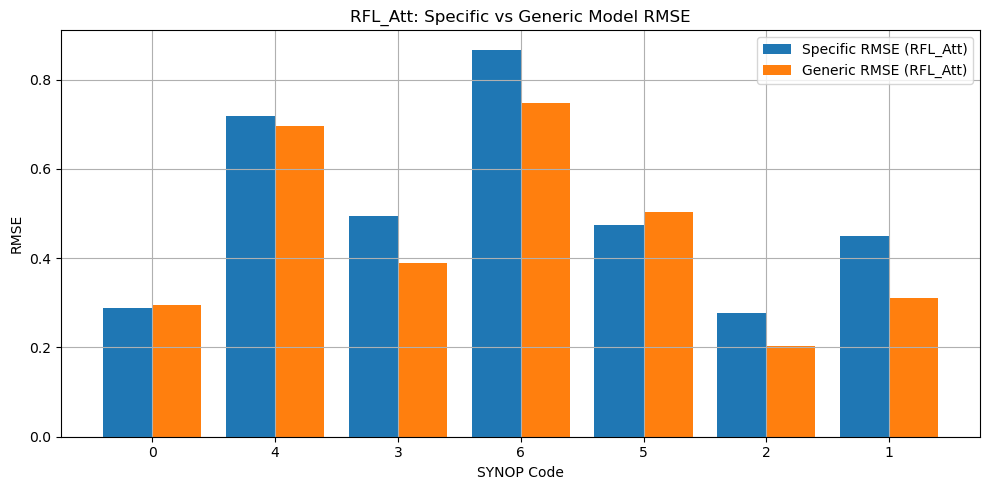

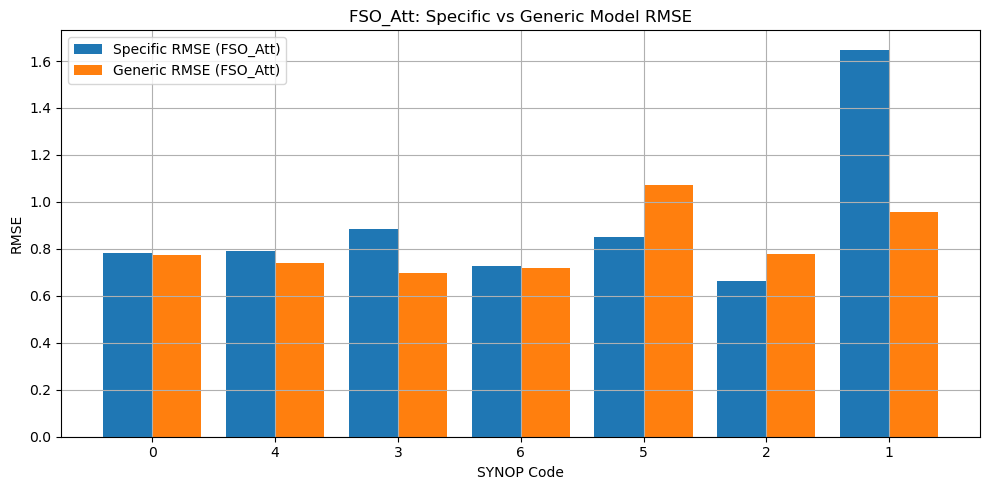

In [364]:
import matplotlib.pyplot as plt
import numpy as np

# Get all SYNOP codes in same order used during modeling
synop_codes = list(predictions_rfl.keys())

# Extract RMSE for each SYNOP code
from sklearn.metrics import mean_squared_error, r2_score

# RFL
specific_rmse_rfl = []
generic_rmse_rfl = []

# FSO
specific_rmse_fso = []
generic_rmse_fso = []

for synop in synop_codes:
    # Specific RFL
    y_pred_spec_rfl, y_true_spec_rfl = predictions_rfl[synop]
    rmse_spec_rfl = np.sqrt(mean_squared_error(y_true_spec_rfl, y_pred_spec_rfl))
    specific_rmse_rfl.append(rmse_spec_rfl)

    # Generic RFL
    X_test_synop_gen_rfl = X_test_rfl_full[X_test_rfl_full["SYNOPCode"] == synop][best_features_rfl]
    y_test_synop_rfl = y_test_rfl[X_test_rfl_full["SYNOPCode"] == synop]
    rmse_gen_rfl = np.sqrt(mean_squared_error(y_test_synop_rfl, generic_model_rfl.predict(X_test_synop_gen_rfl)))
    generic_rmse_rfl.append(rmse_gen_rfl)

    # Specific FSO
    y_pred_spec_fso, y_true_spec_fso = predictions_fso[synop]
    rmse_spec_fso = np.sqrt(mean_squared_error(y_true_spec_fso, y_pred_spec_fso))
    specific_rmse_fso.append(rmse_spec_fso)

    # Generic FSO
    X_test_synop_gen_fso = X_test_fso_full[X_test_fso_full["SYNOPCode"] == synop][best_features_fso]
    y_test_synop_fso = y_test_fso[X_test_fso_full["SYNOPCode"] == synop]
    rmse_gen_fso = np.sqrt(mean_squared_error(y_test_synop_fso, generic_model_fso.predict(X_test_synop_gen_fso)))
    generic_rmse_fso.append(rmse_gen_fso)

# Convert to x-axis indices
x = np.arange(len(synop_codes))

# Bar Chart: RFL_Att 
plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, specific_rmse_rfl, width=0.4, label="Specific RMSE (RFL_Att)")
plt.bar(x + 0.2, generic_rmse_rfl, width=0.4, label="Generic RMSE (RFL_Att)")
plt.xticks(x, synop_codes)
plt.xlabel("SYNOP Code")
plt.ylabel("RMSE")
plt.title("RFL_Att: Specific vs Generic Model RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#  Bar Chart: FSO_Att
plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, specific_rmse_fso, width=0.4, label="Specific RMSE (FSO_Att)")
plt.bar(x + 0.2, generic_rmse_fso, width=0.4, label="Generic RMSE (FSO_Att)")
plt.xticks(x, synop_codes)
plt.xlabel("SYNOP Code")
plt.ylabel("RMSE")
plt.title("FSO_Att: Specific vs Generic Model RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [366]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score


# R² scores
specific_r2_rfl = []
generic_r2_rfl = []
specific_r2_fso = []
generic_r2_fso = []

for synop in synop_codes:
    # RF R² 
    y_pred_spec_rfl, y_true_spec_rfl = predictions_rfl[synop]
    r2_spec_rfl = r2_score(y_true_spec_rfl, y_pred_spec_rfl)
    specific_r2_rfl.append(r2_spec_rfl)

    X_test_synop_gen_rfl = X_test_rfl_full[X_test_rfl_full["SYNOPCode"] == synop][best_features_rfl]
    y_test_synop_rfl = y_test_rfl[X_test_rfl_full["SYNOPCode"] == synop]
    r2_gen_rfl = r2_score(y_test_synop_rfl, generic_model_rfl.predict(X_test_synop_gen_rfl))
    generic_r2_rfl.append(r2_gen_rfl)

    # FSO R²
    y_pred_spec_fso, y_true_spec_fso = predictions_fso[synop]
    r2_spec_fso = r2_score(y_true_spec_fso, y_pred_spec_fso)
    specific_r2_fso.append(r2_spec_fso)

    X_test_synop_gen_fso = X_test_fso_full[X_test_fso_full["SYNOPCode"] == synop][best_features_fso]
    y_test_synop_fso = y_test_fso[X_test_fso_full["SYNOPCode"] == synop]
    r2_gen_fso = r2_score(y_test_synop_fso, generic_model_fso.predict(X_test_synop_gen_fso))
    generic_r2_fso.append(r2_gen_fso)



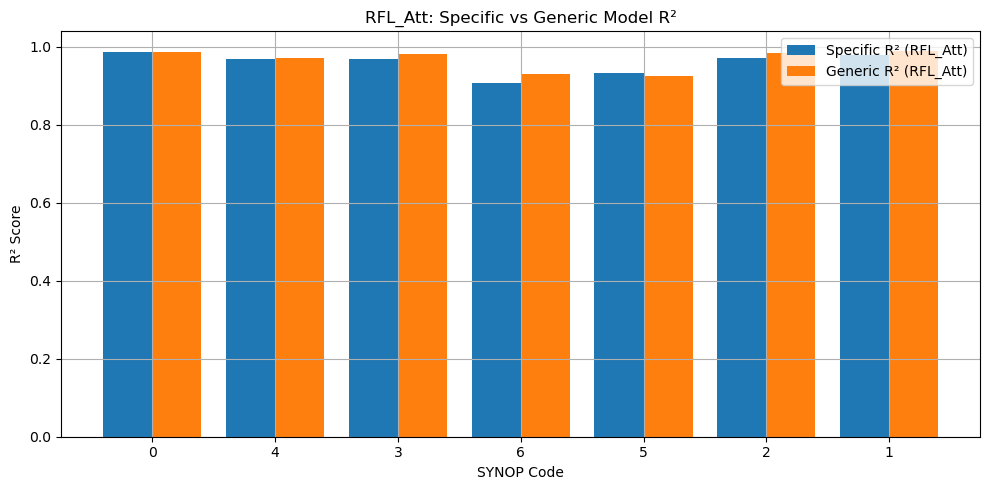

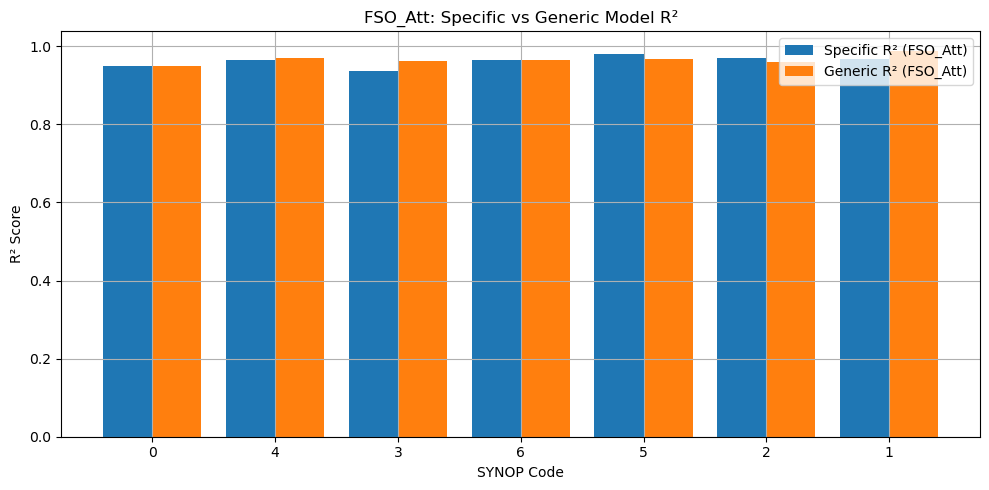

In [367]:
# Bar plots
x = np.arange(len(synop_codes))

# RFL_Att R² Comparison
plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, specific_r2_rfl, width=0.4, label="Specific R² (RFL_Att)")
plt.bar(x + 0.2, generic_r2_rfl, width=0.4, label="Generic R² (RFL_Att)")
plt.xticks(x, synop_codes)
plt.xlabel("SYNOP Code")
plt.ylabel("R² Score")
plt.title("RFL_Att: Specific vs Generic Model R²")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("RFL_R2_Comparison.png")
plt.show()

# FSO_Att R² Comparison
plt.figure(figsize=(10, 5))
plt.bar(x - 0.2, specific_r2_fso, width=0.4, label="Specific R² (FSO_Att)")
plt.bar(x + 0.2, generic_r2_fso, width=0.4, label="Generic R² (FSO_Att)")
plt.xticks(x, synop_codes)
plt.xlabel("SYNOP Code")
plt.ylabel("R² Score")
plt.title("FSO_Att: Specific vs Generic Model R²")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("FSO_R2_Comparison.png")
plt.show()


Scatter Plot


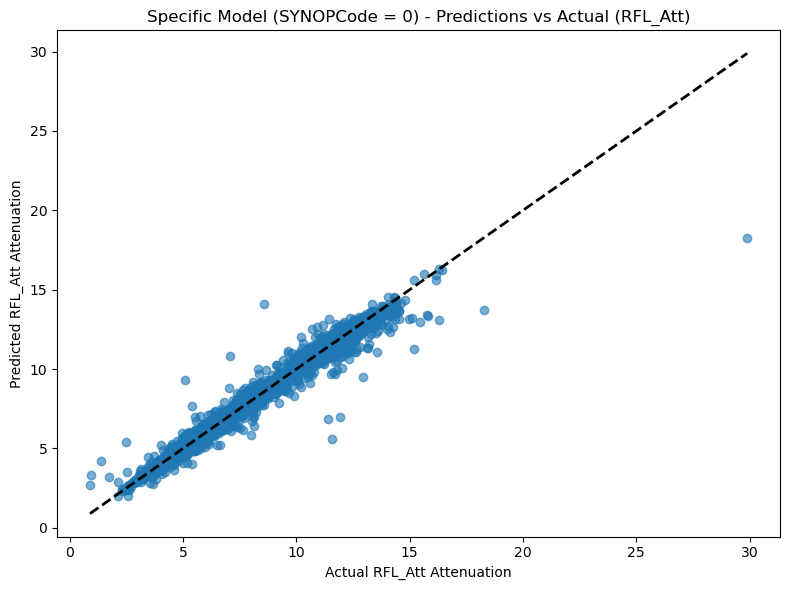

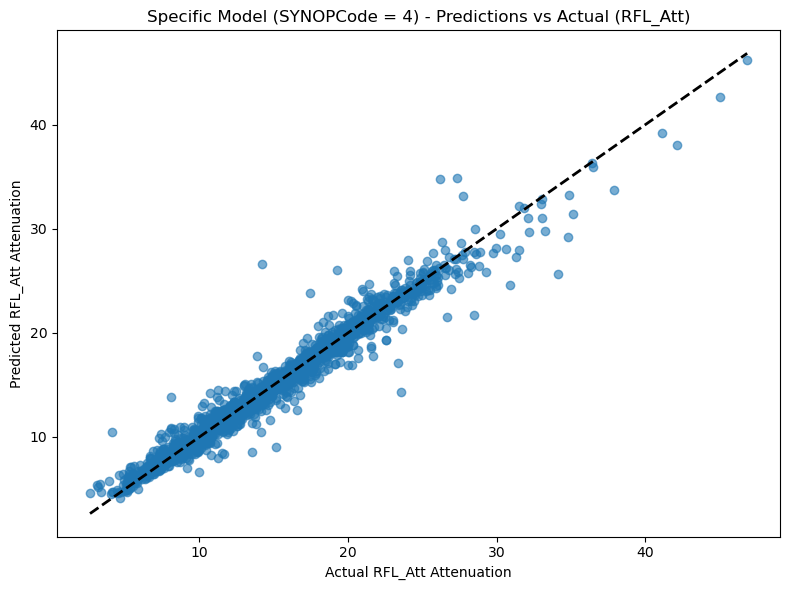

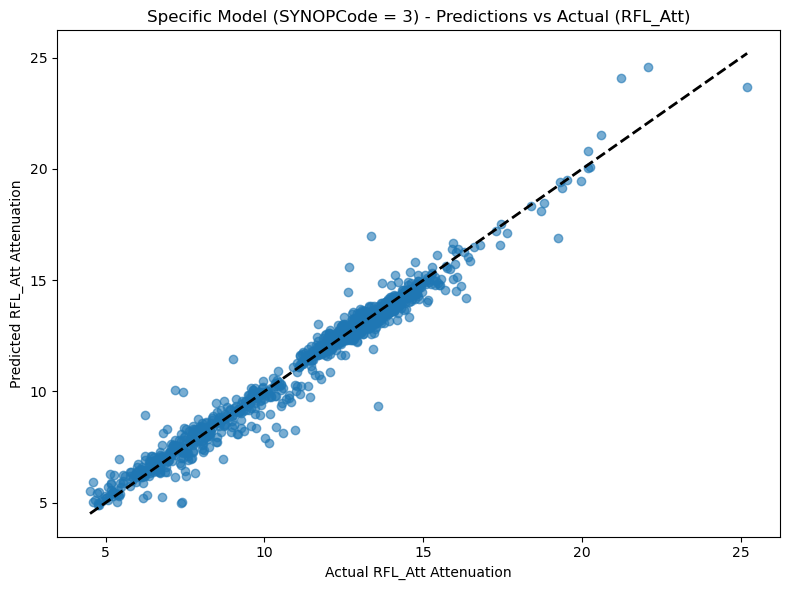

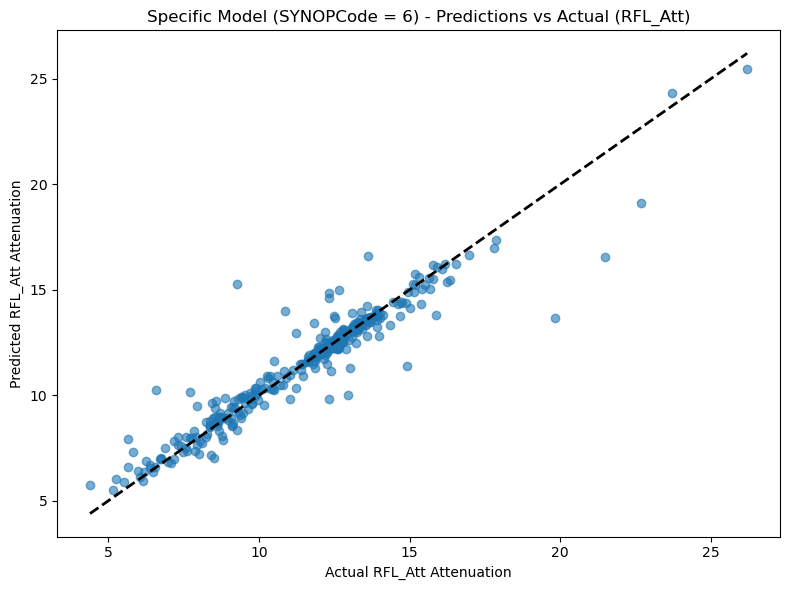

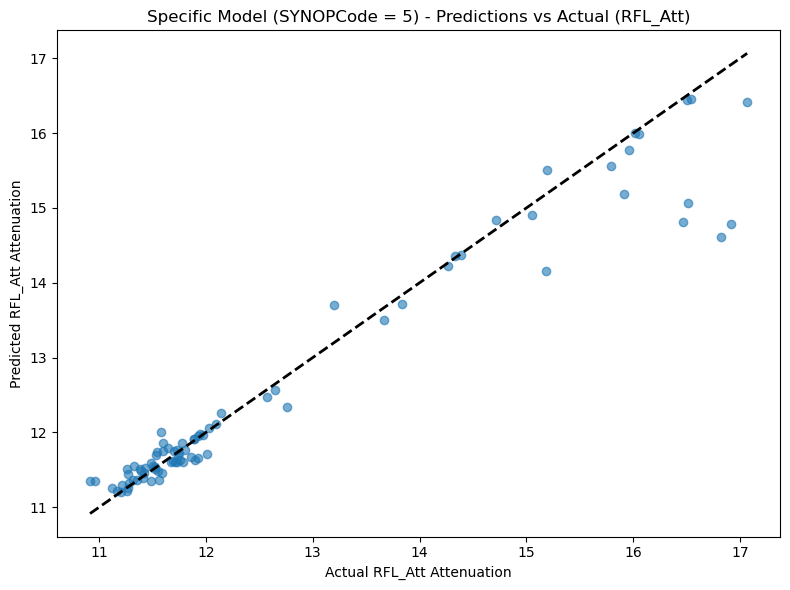

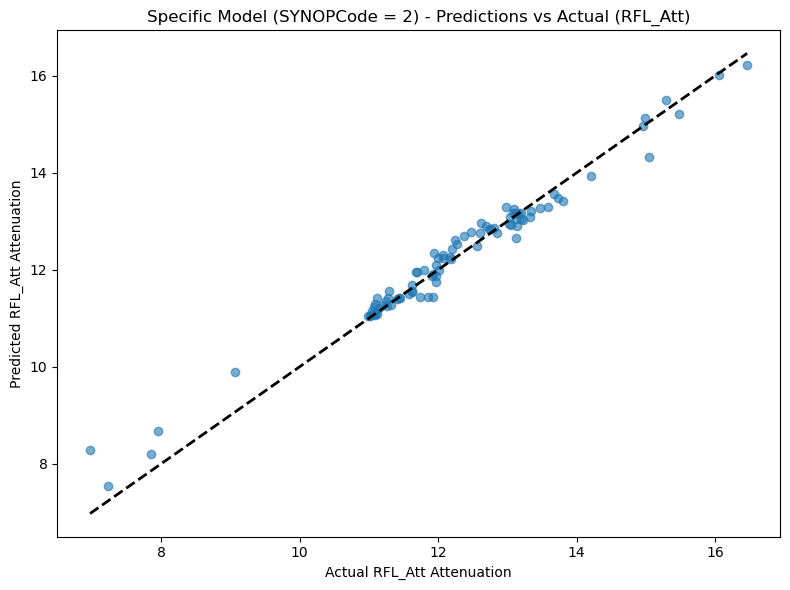

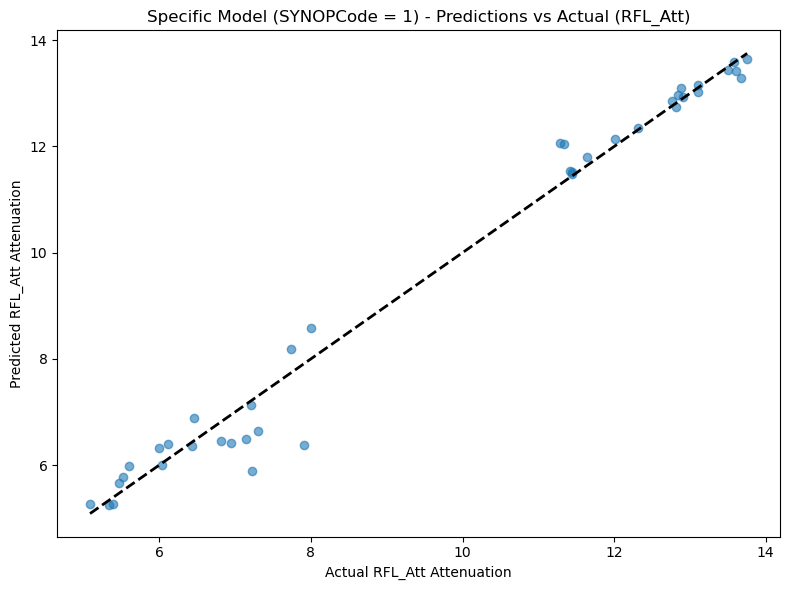

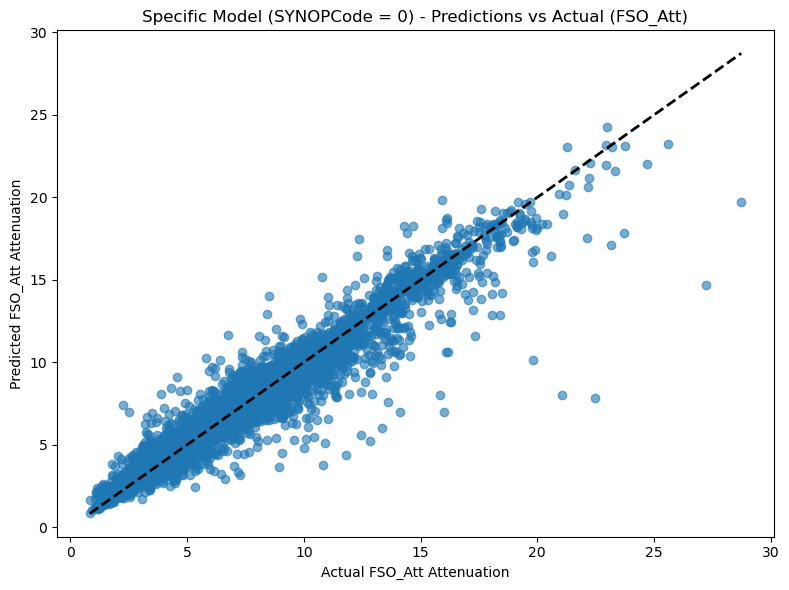

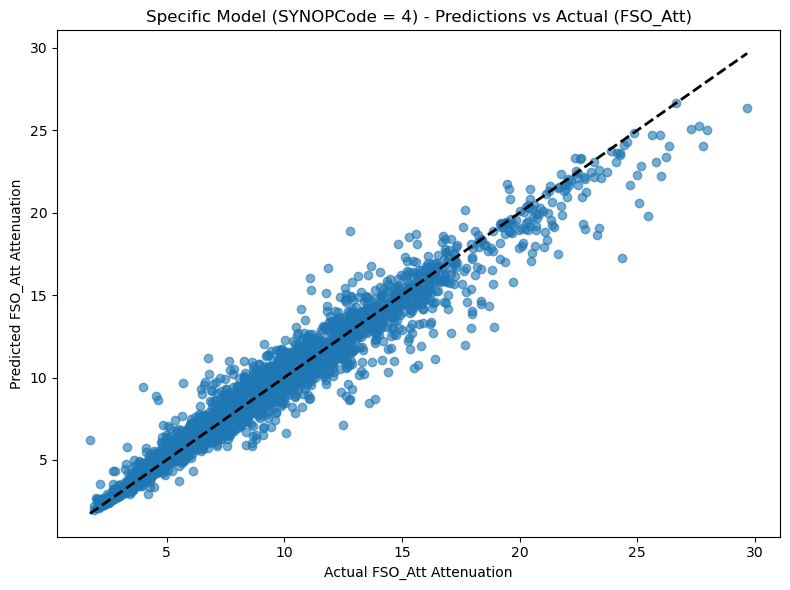

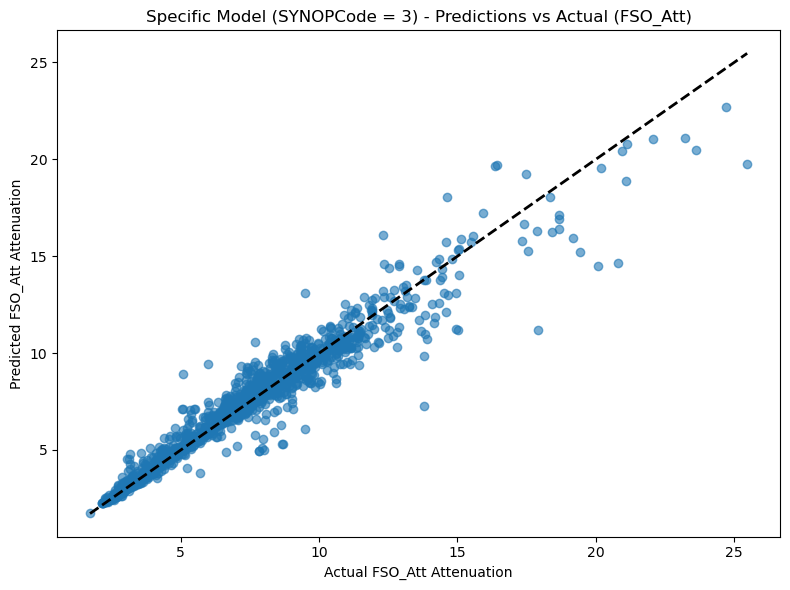

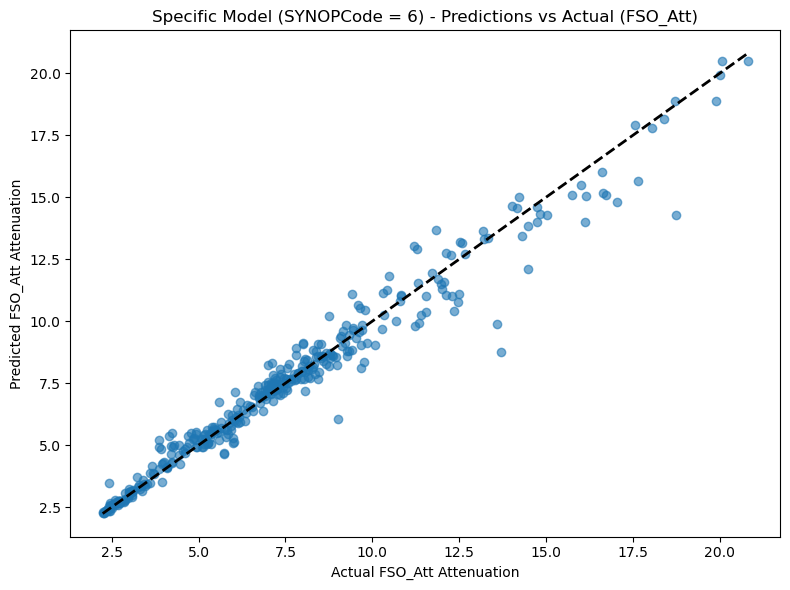

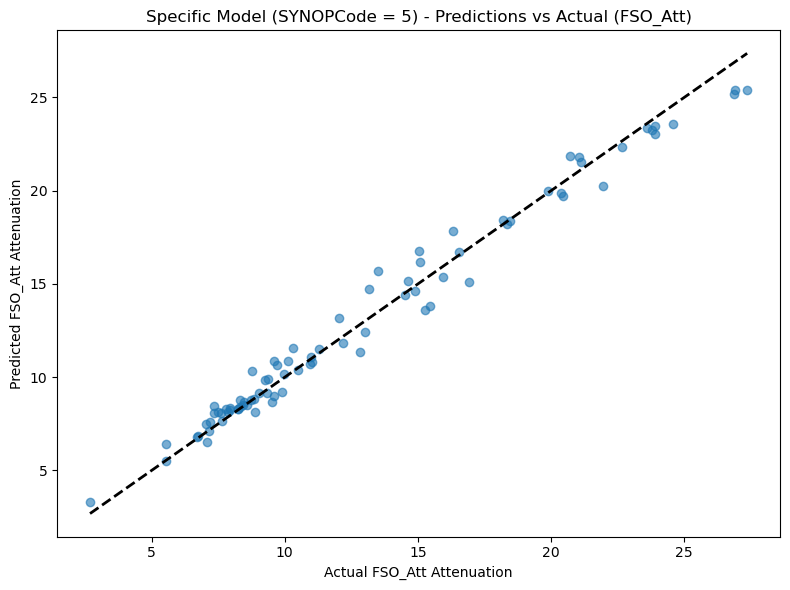

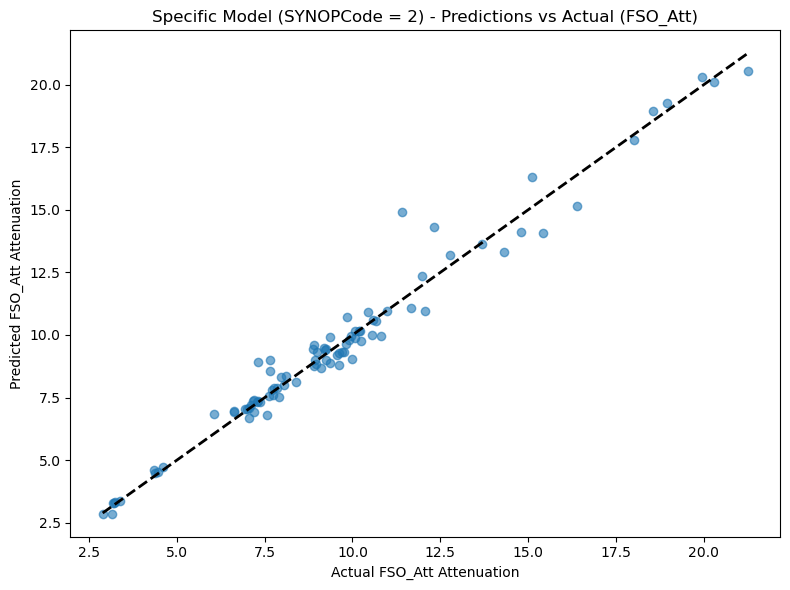

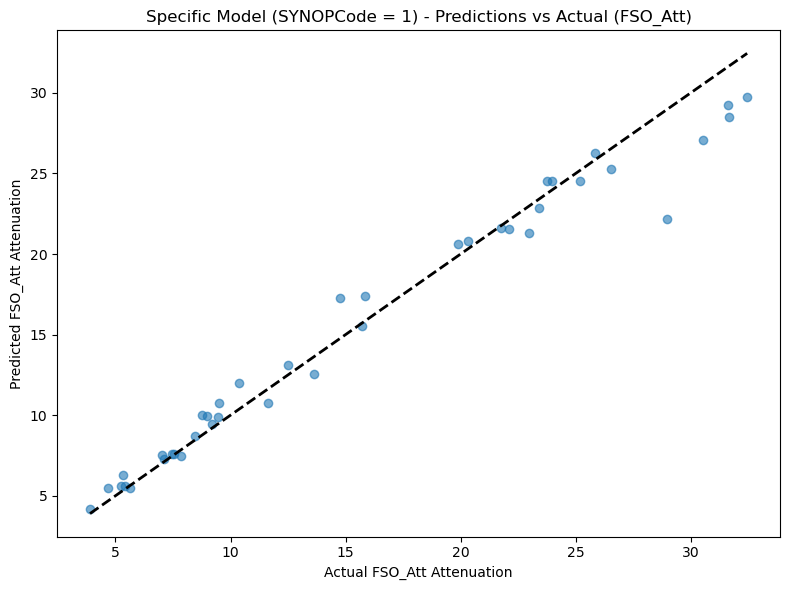

In [370]:
import matplotlib.pyplot as plt
import os

# Create output directory if not exists
output_dir = "scatter_plots"
os.makedirs(output_dir, exist_ok=True)

# Function to plot and save predictions vs actual values
def plot_specific_model_predictions(predictions, target_name):
    for synop, (y_pred, y_true) in predictions.items():
        plt.figure(figsize=(8, 6))
        plt.scatter(y_true, y_pred, alpha=0.6)
        plt.xlabel(f"Actual {target_name} Attenuation")
        plt.ylabel(f"Predicted {target_name} Attenuation")
        plt.title(f"Specific Model (SYNOPCode = {synop}) - Predictions vs Actual ({target_name})")
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
        plt.tight_layout()

        # Save the figure
        filename = f"{target_name}_SYNOP_{synop}.png"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=300)
        plt.show()

# Plot and save for specific RFL_Att models
plot_specific_model_predictions(predictions_rfl, "RFL_Att")

# Plot and save for specific FSO_Att models
plot_specific_model_predictions(predictions_fso, "FSO_Att")


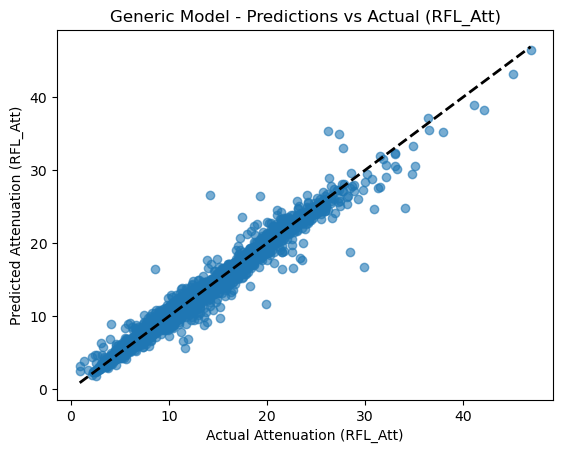

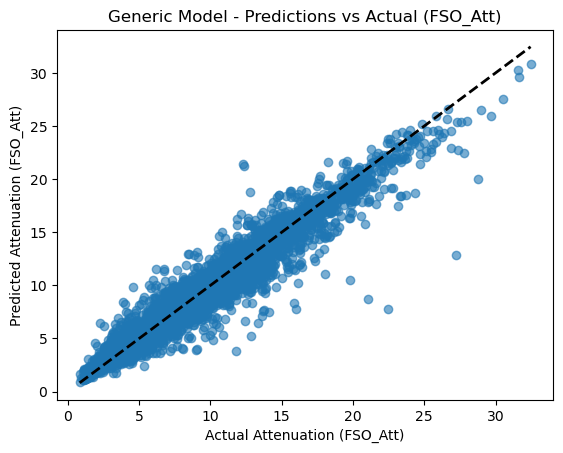

In [282]:
# Visualize predictions vs actual for RFL_Att
plt.scatter(y_test_rfl, generic_predictions_rfl, alpha=0.6)
plt.xlabel("Actual Attenuation (RFL_Att)")
plt.ylabel("Predicted Attenuation (RFL_Att)")
plt.title("Generic Model - Predictions vs Actual (RFL_Att)")
plt.plot([y_test_rfl.min(), y_test_rfl.max()], [y_test_rfl.min(), y_test_rfl.max()], 'k--', lw=2)
plt.show()

# Visualize predictions vs actual for FSO_Att
plt.scatter(y_test_fso, generic_predictions_fso, alpha=0.6)
plt.xlabel("Actual Attenuation (FSO_Att)")
plt.ylabel("Predicted Attenuation (FSO_Att)")
plt.title("Generic Model - Predictions vs Actual (FSO_Att)")
plt.plot([y_test_fso.min(), y_test_fso.max()], [y_test_fso.min(), y_test_fso.max()], 'k--', lw=2)
plt.show()


**Part B: RF and FSO Attenuation Prediction**

Objective
In this notebook, we will:

Implement and compare three models:

**Method 1: Independent models for RF and FSO attenuation - Done in Part A**

**Method 2: Cascaded model using RF predictions for FSO attenuation**

**Method 3: Cascaded model using FSO predictions for RF attenuation**

Analyzing the correlation between RF and FSO attenuations and 
Comparing model performances using RMSE, R², and correlation metrics

**Method 2 : Cascaded model using RF predictions for FSO attenuation**

In [285]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Step 1: Train RF model (generic)
X_train_rf = data.loc[X_train_rfl.index, best_features_rfl]
X_test_rf = data.loc[X_test_rfl.index, best_features_rfl]
y_train_rf = y_train_rfl

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

# Step 2: Predict RF attenuation on training and testing data
rf_train_pred = rf_model.predict(X_train_rf)
rf_test_pred = rf_model.predict(X_test_rf)

# Step 3: Augment FSO features with predicted RF
X_train_fso_aug = data.loc[X_train_fso.index, best_features_fso].copy()
X_train_fso_aug['Predicted_RF'] = rf_train_pred

X_test_fso_aug = data.loc[X_test_fso.index, best_features_fso].copy()
X_test_fso_aug['Predicted_RF'] = rf_test_pred

# Step 4: Train model to predict FSO using augmented features
cascaded_fso_model = RandomForestRegressor(n_estimators=100, random_state=42)
cascaded_fso_model.fit(X_train_fso_aug, y_train_fso)

# Step 5: Evaluate
fso_cascaded_pred = cascaded_fso_model.predict(X_test_fso_aug)
rmse_fso_cascaded = np.sqrt(mean_squared_error(y_test_fso, fso_cascaded_pred))
r2_fso_cascaded = r2_score(y_test_fso, fso_cascaded_pred)

print("📡 Cascaded Model (RF → FSO)")
print(f"RMSE: {rmse_fso_cascaded:.4f}")
print(f"R²: {r2_fso_cascaded:.4f}")


📡 Cascaded Model (RF → FSO)
RMSE: 0.7931
R²: 0.9581


Correlation Preservations

In [286]:
from scipy.stats import pearsonr
import numpy as np
import pandas as pd

# Helper function to compute normalized MI
def compute_normalized_mi(x, y, bins=20):
    joint_hist, _, _ = np.histogram2d(x, y, bins=bins)
    joint_prob = joint_hist / np.sum(joint_hist)
    p_rf = np.sum(joint_prob, axis=1)
    p_fso = np.sum(joint_prob, axis=0)

    mutual_info = 0.0
    for i in range(bins):
        for j in range(bins):
            pxy = joint_prob[i, j]
            if pxy > 0:
                mutual_info += pxy * np.log2(pxy / (p_rf[i] * p_fso[j]))

    joint_entropy = -np.sum([p * np.log2(p) for p in joint_prob.flatten() if p > 0])
    return mutual_info / joint_entropy if joint_entropy > 0 else np.nan

# Evaluate Pearson and NMI correlation for each SYNOP code
pearson_corrs_rf_fso = []  
nmi_corrs_rf_fso = []      
synop_labels = []          

for synop_code in sorted(data['SYNOPCode'].unique()):
    mask_rf = X_test_rf['SYNOPCode'] == synop_code
    mask_fso = X_test_fso['SYNOPCode'] == synop_code

    rf_values = rf_test_pred[mask_rf]
    fso_values = fso_cascaded_pred[mask_fso]

    if len(rf_values) > 1 and len(fso_values) > 1:
        pearson_val = pearsonr(rf_values, fso_values)[0]
        nmi_val = compute_normalized_mi(rf_values, fso_values)
    else:
        pearson_val = nmi_val = np.nan

    pearson_corrs_rf_fso.append(abs(pearson_val))  
    nmi_corrs_rf_fso.append(nmi_val)
    synop_labels.append(str(synop_code))  

# Create DataFrame
cascaded_rf_fso_correlation = pd.DataFrame({
    "SYNOP Code": synop_labels,
    "Pearson Correlation": pearson_corrs_rf_fso,
    "Normalized MI": nmi_corrs_rf_fso
})

styled_df = cascaded_rf_fso_correlation.round(4).reset_index(drop=True)
styled_df.index += 1  

# Display the styled table
display(
    styled_df.style
    .set_table_styles([{
        'selector': 'th, td',
        'props': [('text-align', 'center')]
    }])
    .set_properties(**{'text-align': 'center'})
    .set_caption("📊 Correlation Preservation Results (Cascaded RF → FSO)")
)


,SYNOP Code,Pearson Correlation,Normalized MI
1,0,0.300700,0.071000
2,1,0.409700,0.463800
3,2,0.510700,0.277900
4,3,0.159900,0.094500
5,4,0.367800,0.071000
6,5,0.829400,0.346500
7,6,0.242600,0.139500


C:\Users\91984\AppData\Local\Temp\ipykernel_2448\1256220367.py:22: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\91984\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


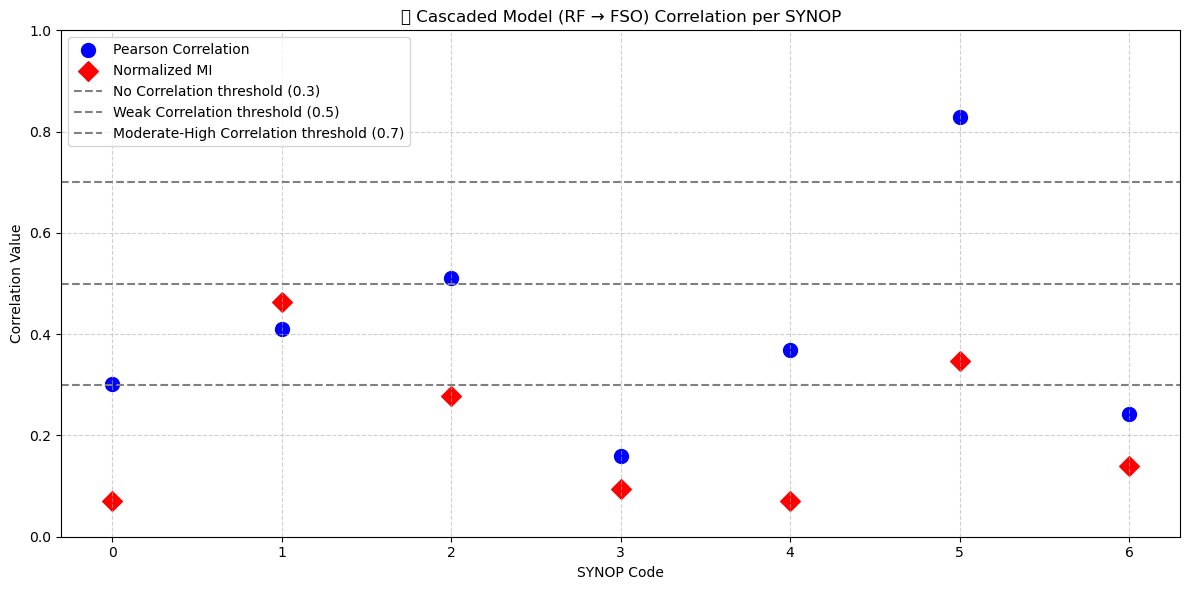

In [287]:
# Plotting
x = np.arange(len(synop_labels)) 
plt.figure(figsize=(12, 6))

# Plot Pearson
plt.scatter(x, pearson_corrs_rf_fso, color='blue', s=100, marker='o', label="Pearson Correlation")

# Plot Normalized MI
plt.scatter(x, nmi_corrs_rf_fso, color='red', s=100, marker='D', label="Normalized MI")

# Labels and grid
plt.xticks(x, synop_labels)
plt.xlabel("SYNOP Code")
plt.ylabel("Correlation Value")
plt.title("📈 Cascaded Model (RF → FSO) Correlation per SYNOP")
plt.axhline(0.3, color='gray', linestyle='--', label="No Correlation threshold (0.3)")
plt.axhline(0.5, color='gray', linestyle='--', label="Weak Correlation threshold (0.5)")
plt.axhline(0.7, color='gray', linestyle='--', label="Moderate-High Correlation threshold (0.7)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


 Real RF-FSO correlation per synop

In [288]:
#To get the real RF-FSO correlation per synop

def get_correlation_level(corr_value):
    if corr_value < 0.3:
        return "No/Weak Correlation"
    elif corr_value < 0.5:
        return "Low Correlation"
    elif corr_value < 0.7:
        return "Moderate Correlation"
    else:
        return "Strong Correlation"

# Real RF-FSO correlation per SYNOP
real_corrs = []
synop_codes_sorted = sorted(data['SYNOPCode'].unique())

for synop_code in synop_codes_sorted:
    mask_rf = X_test_rfl['SYNOPCode'] == synop_code
    mask_fso = X_test_fso['SYNOPCode'] == synop_code
    
    rf_real = y_test_rfl[mask_rf]
    fso_real = y_test_fso[mask_fso]
    
    if len(rf_real) > 1 and len(fso_real) > 1:
        corr_real, _ = pearsonr(rf_real, fso_real)
        real_corrs.append(abs(corr_real))  # take absolute for fair comparison
    else:
        real_corrs.append(np.nan)

C:\Users\91984\AppData\Local\Temp\ipykernel_2448\3771391914.py:24: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\91984\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


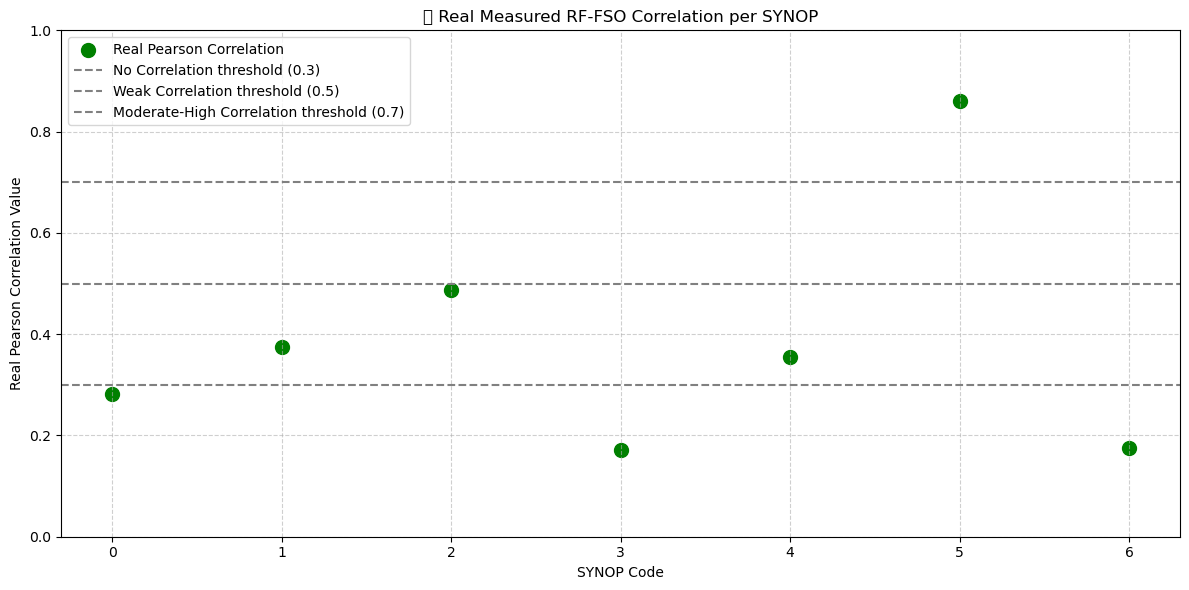

In [289]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare X-axis positions
x = np.arange(len(synop_codes_sorted))

# Plot
plt.figure(figsize=(12, 6))
plt.scatter(x, real_corrs, color='green', s=100, marker='o', label="Real Pearson Correlation")

# Add reference lines
plt.axhline(0.3, color='gray', linestyle='--', label="No Correlation threshold (0.3)")
plt.axhline(0.5, color='gray', linestyle='--', label="Weak Correlation threshold (0.5)")
plt.axhline(0.7, color='gray', linestyle='--', label="Moderate-High Correlation threshold (0.7)")

# Labels, title, etc.
plt.xticks(x, synop_codes_sorted)
plt.xlabel("SYNOP Code")
plt.ylabel("Real Pearson Correlation Value")
plt.title("📈 Real Measured RF-FSO Correlation per SYNOP")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [290]:
# To create Comparison table for both Real and Predicted correlation
comparison_rf_fso_df = pd.DataFrame({
    "SYNOP Code": synop_codes_sorted,
    "Real Pearson Correlation": real_corrs,
    "Real Correlation Level": [get_correlation_level(c) for c in real_corrs],
    "Predicted Pearson Correlation": pearson_corrs_rf_fso,  
    "Predicted Correlation Level": [get_correlation_level(c) for c in pearson_corrs_rf_fso],  
})


In [291]:
# Show the table
comparison_rf_fso_df = comparison_rf_fso_df.round(4)
comparison_rf_fso_df.index += 1 
display(
    comparison_rf_fso_df.style.set_properties(**{'text-align': 'center'}).set_caption(
        "📊 Comparison of Real vs Predicted RF-FSO Correlation Ranges"
    )
)


,SYNOP Code,Real Pearson Correlation,Real Correlation Level,Predicted Pearson Correlation,Predicted Correlation Level
1,0,0.282000,No/Weak Correlation,0.300700,Low Correlation
2,1,0.374100,Low Correlation,0.409700,Low Correlation
3,2,0.488000,Low Correlation,0.510700,Moderate Correlation
4,3,0.170400,No/Weak Correlation,0.159900,No/Weak Correlation
5,4,0.355300,Low Correlation,0.367800,Low Correlation
6,5,0.860200,Strong Correlation,0.829400,Strong Correlation
7,6,0.174800,No/Weak Correlation,0.242600,No/Weak Correlation


Plot to show Real vs Predicted RF-FSO Correlation per SYNOP Code (Scatter Plot)

C:\Users\91984\AppData\Local\Temp\ipykernel_2448\520561255.py:28: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\91984\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


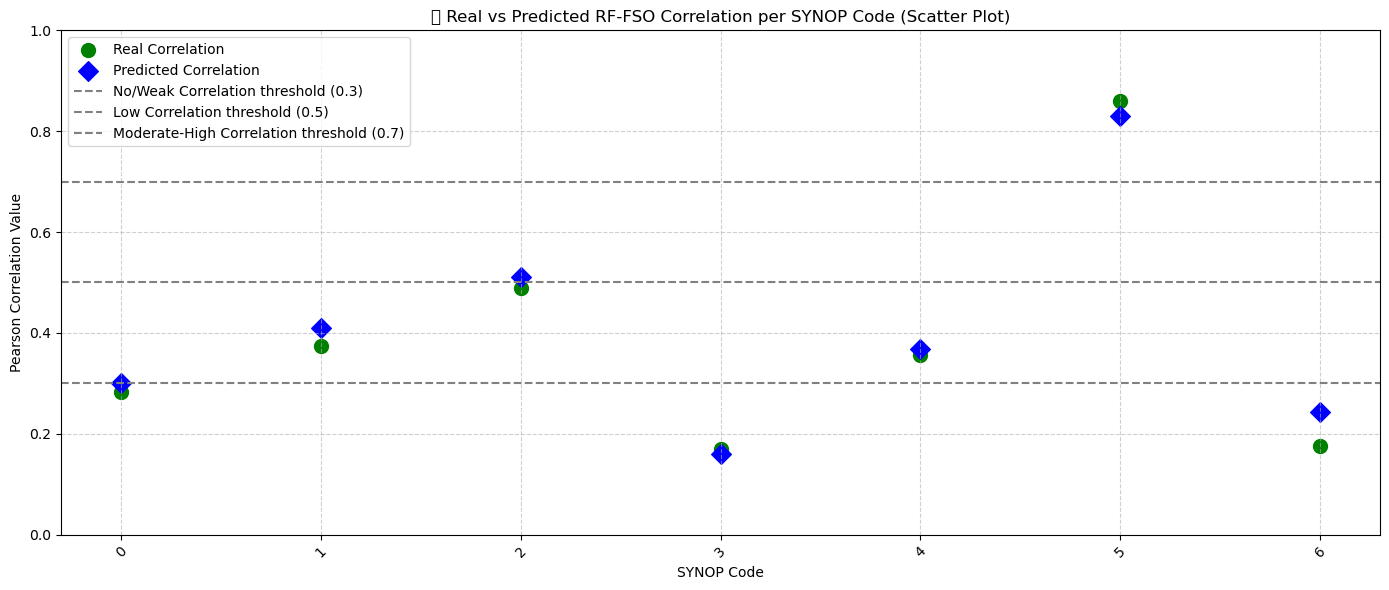

In [292]:
import matplotlib.pyplot as plt
import numpy as np

# Getting the data
synop_codes_sorted = comparison_rf_fso_df["SYNOP Code"].tolist()
real_corrs_plot = comparison_rf_fso_df["Real Pearson Correlation"].tolist()
pred_corrs_plot = comparison_rf_fso_df["Predicted Pearson Correlation"].tolist()

# Set X-axis positions
x = np.arange(len(synop_codes_sorted))

# Create scatter plot
plt.figure(figsize=(14, 6))
plt.scatter(x, real_corrs_plot, color='green', s=100, marker='o', label='Real Correlation')
plt.scatter(x, pred_corrs_plot, color='blue', s=100, marker='D', label='Predicted Correlation')

# Add labels and titles
plt.xticks(x, synop_codes_sorted, rotation=45)
plt.xlabel("SYNOP Code")
plt.ylabel("Pearson Correlation Value")
plt.title("📈 Real vs Predicted RF-FSO Correlation per SYNOP Code (Scatter Plot)")
plt.axhline(0.3, color='gray', linestyle='--', label="No/Weak Correlation threshold (0.3)")
plt.axhline(0.5, color='gray', linestyle='--', label="Low Correlation threshold (0.5)")
plt.axhline(0.7, color='gray', linestyle='--', label="Moderate-High Correlation threshold (0.7)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**Method 3: Cascaded model using FSO predictions for RF attenuation**

In [293]:
# Step 1: Train FSO model (generic)
X_train_fso_cas = data.loc[X_train_fso.index, best_features_fso]
X_test_fso_cas = data.loc[X_test_fso.index, best_features_fso]
y_train_fso_cas = y_train_fso

fso_model = RandomForestRegressor(n_estimators=100, random_state=42)
fso_model.fit(X_train_fso_cas, y_train_fso_cas)

# Step 2: Predict FSO attenuation on training and test data
fso_train_pred = fso_model.predict(X_train_fso_cas)
fso_test_pred = fso_model.predict(X_test_fso_cas)

# Step 3: Add predicted FSO as a new feature to RF data
X_train_rf_aug = data.loc[X_train_rfl.index, best_features_rfl].copy()
X_train_rf_aug['Predicted_FSO'] = fso_train_pred

X_test_rf_aug = data.loc[X_test_rfl.index, best_features_rfl].copy()
X_test_rf_aug['Predicted_FSO'] = fso_test_pred

# Step 4: Train RF model with augmented features
cascaded_rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
cascaded_rf_model.fit(X_train_rf_aug, y_train_rfl)

# Step 5: Evaluate
rf_cascaded_pred = cascaded_rf_model.predict(X_test_rf_aug)
rmse_rf_cascaded = np.sqrt(mean_squared_error(y_test_rfl, rf_cascaded_pred))
r2_rf_cascaded = r2_score(y_test_rfl, rf_cascaded_pred)

print("🔁 Cascaded Model (FSO → RF)")
print(f"RMSE: {rmse_rf_cascaded:.4f}")
print(f"R²: {r2_rf_cascaded:.4f}")


🔁 Cascaded Model (FSO → RF)
RMSE: 0.4519
R²: 0.9828


Correlation Preservations

In [294]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Helper function to compute Normalized Mutual Information (NMI)
def compute_normalized_mi(x, y, bins=20):
    joint_hist, _, _ = np.histogram2d(x, y, bins=bins)
    joint_prob = joint_hist / np.sum(joint_hist)
    p_rf = np.sum(joint_prob, axis=1)
    p_fso = np.sum(joint_prob, axis=0)

    mutual_info = 0.0
    for i in range(bins):
        for j in range(bins):
            pxy = joint_prob[i, j]
            if pxy > 0:
                mutual_info += pxy * np.log2(pxy / (p_rf[i] * p_fso[j]))

    joint_entropy = -np.sum([p * np.log2(p) for p in joint_prob.flatten() if p > 0])
    return mutual_info / joint_entropy if joint_entropy > 0 else np.nan

# Correlation Analysis
pearson_corrs_fso_rf = []  
nmi_corrs_fso_rf = []      
synop_labels = []          

# Loop through each SYNOP code
for synop_code in sorted(data['SYNOPCode'].unique()):
    # Mask for current SYNOP code
    mask_rf = X_test_rf_aug['SYNOPCode'] == synop_code
    mask_fso = X_test_rf_aug['SYNOPCode'] == synop_code  

    # Select RF and FSO predictions
    rf_values = rf_cascaded_pred[mask_rf]
    fso_values = fso_test_pred[mask_fso]

    if len(rf_values) > 1 and len(fso_values) > 1:
        pearson_val = pearsonr(fso_values, rf_values)[0]  
        nmi_val = compute_normalized_mi(fso_values, rf_values)
    else:
        pearson_val = nmi_val = np.nan

    synop_labels.append(str(synop_code))
    pearson_corrs_fso_rf.append(abs(pearson_val))  
    nmi_corrs_fso_rf.append(nmi_val)

# Create summary table
cascaded_fso_rf_correlation = pd.DataFrame({
    "SYNOP Code": synop_labels,
    "Pearson Correlation": pearson_corrs_fso_rf,
    "Normalized MI": nmi_corrs_fso_rf
})

cascaded_fso_rf_correlation.index += 1  

# Display
styled_df = cascaded_fso_rf_correlation.style.set_properties(**{'text-align': 'center'})\
    .set_table_styles([{
        'selector': 'th, td',
        'props': [('text-align', 'center')]
    }])\
    .set_caption("📊 Correlation Preservation Results (Cascaded FSO → RF)")

display(styled_df)


,SYNOP Code,Pearson Correlation,Normalized MI
1,0,0.298683,0.072245
2,1,0.382629,0.504869
3,2,0.508951,0.297741
4,3,0.157213,0.088893
5,4,0.360655,0.071515
6,5,0.838026,0.352037
7,6,0.232869,0.143429


C:\Users\91984\AppData\Local\Temp\ipykernel_2448\813477377.py:22: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\91984\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


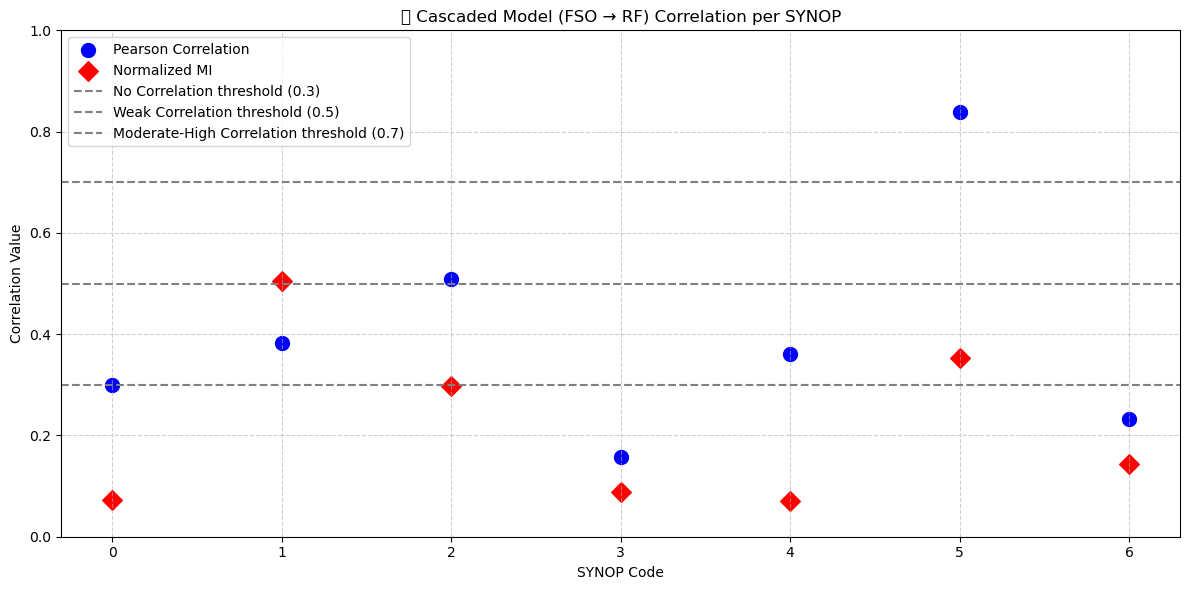

In [295]:
#  Plot Cascaded Model (FSO → RF) Correlation per SYNOP
x = np.arange(len(synop_labels))
plt.figure(figsize=(12, 6))

# Plot Pearson
plt.scatter(x, pearson_corrs_fso_rf, color='blue', s=100, marker='o', label="Pearson Correlation")

# Plot Normalized MI
plt.scatter(x, nmi_corrs_fso_rf, color='red', s=100, marker='D', label="Normalized MI")

# Labels and grid
plt.xticks(x, synop_labels)
plt.xlabel("SYNOP Code")
plt.ylabel("Correlation Value")
plt.title("📈 Cascaded Model (FSO → RF) Correlation per SYNOP")
plt.axhline(0.3, color='gray', linestyle='--', label="No Correlation threshold (0.3)")
plt.axhline(0.5, color='gray', linestyle='--', label="Weak Correlation threshold (0.5)")
plt.axhline(0.7, color='gray', linestyle='--', label="Moderate-High Correlation threshold (0.7)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [296]:
# Create comparison table for FSO-RF 
comparison_fso_rf_df = pd.DataFrame({
    "SYNOP Code": synop_codes_sorted,
    "Real Pearson Correlation": real_corrs,
    "Real Correlation Level": [get_correlation_level(c) for c in real_corrs],
    "Predicted Pearson Correlation": pearson_corrs_fso_rf,  
    "Predicted Correlation Level": [get_correlation_level(c) for c in pearson_corrs_fso_rf],  
})


In [297]:
# Display 
comparison_fso_rf_df = comparison_fso_rf_df.round(4)
comparison_fso_rf_df.index += 1
display(
    comparison_fso_rf_df.style.set_properties(**{'text-align': 'center'}).set_caption(
        "📊 Comparison of Real vs Predicted FSO-RF Correlation Ranges"
    )
)


,SYNOP Code,Real Pearson Correlation,Real Correlation Level,Predicted Pearson Correlation,Predicted Correlation Level
1,0,0.282000,No/Weak Correlation,0.298700,No/Weak Correlation
2,1,0.374100,Low Correlation,0.382600,Low Correlation
3,2,0.488000,Low Correlation,0.509000,Moderate Correlation
4,3,0.170400,No/Weak Correlation,0.157200,No/Weak Correlation
5,4,0.355300,Low Correlation,0.360700,Low Correlation
6,5,0.860200,Strong Correlation,0.838000,Strong Correlation
7,6,0.174800,No/Weak Correlation,0.232900,No/Weak Correlation


Plot to show real vs Predicted FSO-RF Correlation per SYNOP Code (Scatter Plot)

C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2360425844.py:28: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\91984\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


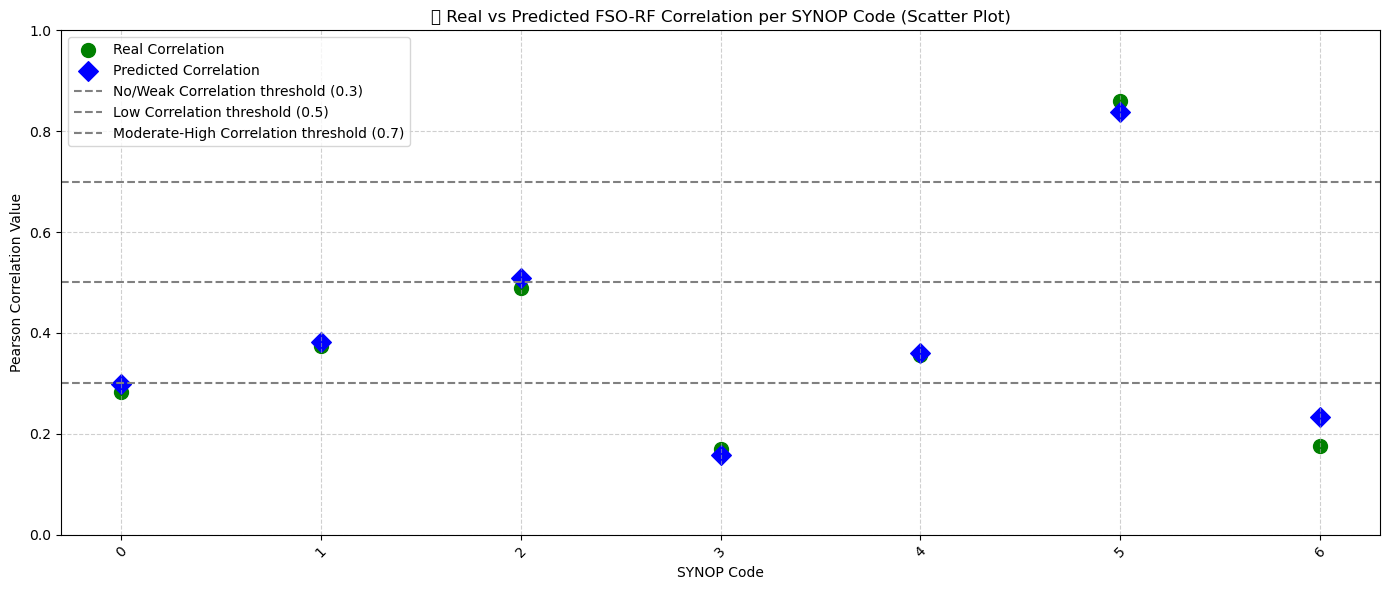

In [298]:
import matplotlib.pyplot as plt
import numpy as np

# Get the data
synop_codes_sorted = comparison_fso_rf_df["SYNOP Code"].tolist()
real_corrs_plot = comparison_fso_rf_df["Real Pearson Correlation"].tolist()
pred_corrs_plot = comparison_fso_rf_df["Predicted Pearson Correlation"].tolist()

# Set X-axis positions
x = np.arange(len(synop_codes_sorted))

# Create scatter plot
plt.figure(figsize=(14, 6))
plt.scatter(x, real_corrs_plot, color='green', s=100, marker='o', label='Real Correlation')
plt.scatter(x, pred_corrs_plot, color='blue', s=100, marker='D', label='Predicted Correlation')

# Add labels and titles
plt.xticks(x, synop_codes_sorted, rotation=45)
plt.xlabel("SYNOP Code")
plt.ylabel("Pearson Correlation Value")
plt.title("📈 Real vs Predicted FSO-RF Correlation per SYNOP Code (Scatter Plot)")
plt.axhline(0.3, color='gray', linestyle='--', label="No/Weak Correlation threshold (0.3)")
plt.axhline(0.5, color='gray', linestyle='--', label="Low Correlation threshold (0.5)")
plt.axhline(0.7, color='gray', linestyle='--', label="Moderate-High Correlation threshold (0.7)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Comparisons of All Models

In [299]:
import pandas as pd

# Create a dictionary with all model evaluation metrics
comparison_data = {
    'Model': [
        'Specific RF (Avg)', 'Specific FSO (Avg)',
        'Generic RF', 'Generic FSO',
        'Tuned RF', 'Tuned FSO',
        'Optimized RF', 'Optimized FSO',
        'Cascaded RF → FSO', 'Cascaded FSO → RF'
    ],
    'RMSE': [
        avg_rmse_rfl_method1, avg_rmse_fso_method1,
        rmse_generic_rfl, rmse_generic_fso,
        rmse_rfl_tuned, rmse_fso_tuned,
        rf_optimized_rmse_rfl, rf_optimized_rmse_fso,
        rmse_fso_cascaded, rmse_rf_cascaded
    ],
    'R²': [
        avg_r2_rfl_method1, avg_r2_fso_method1,
        r2_generic_rfl, r2_generic_fso,
        r2_rfl_tuned, r2_fso_tuned,
        rf_optimized_r2_rfl, rf_optimized_r2_fso,
        r2_fso_cascaded, r2_rf_cascaded
    ]
}

# Convert to DataFrame
comparison_table = pd.DataFrame(comparison_data)

# Reset index starting from 1
comparison_table.index = comparison_table.index + 1

# Display the table
print("\n📊 Model Performance Comparison Table:")
print(comparison_table.round(4))



📊 Model Performance Comparison Table:
                 Model    RMSE      R²
1    Specific RF (Avg)  0.5098  0.9595
2   Specific FSO (Avg)  0.9070  0.9616
3           Generic RF  0.4592  0.9822
4          Generic FSO  0.7601  0.9615
5             Tuned RF  0.4592  0.9822
6            Tuned FSO  0.7712  0.9604
7         Optimized RF  0.4592  0.9822
8        Optimized FSO  0.7712  0.9604
9    Cascaded RF → FSO  0.7931  0.9581
10   Cascaded FSO → RF  0.4519  0.9828


Plot to show Comparisons

C:\Users\91984\AppData\Local\Temp\ipykernel_2448\736327118.py:39: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\91984\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


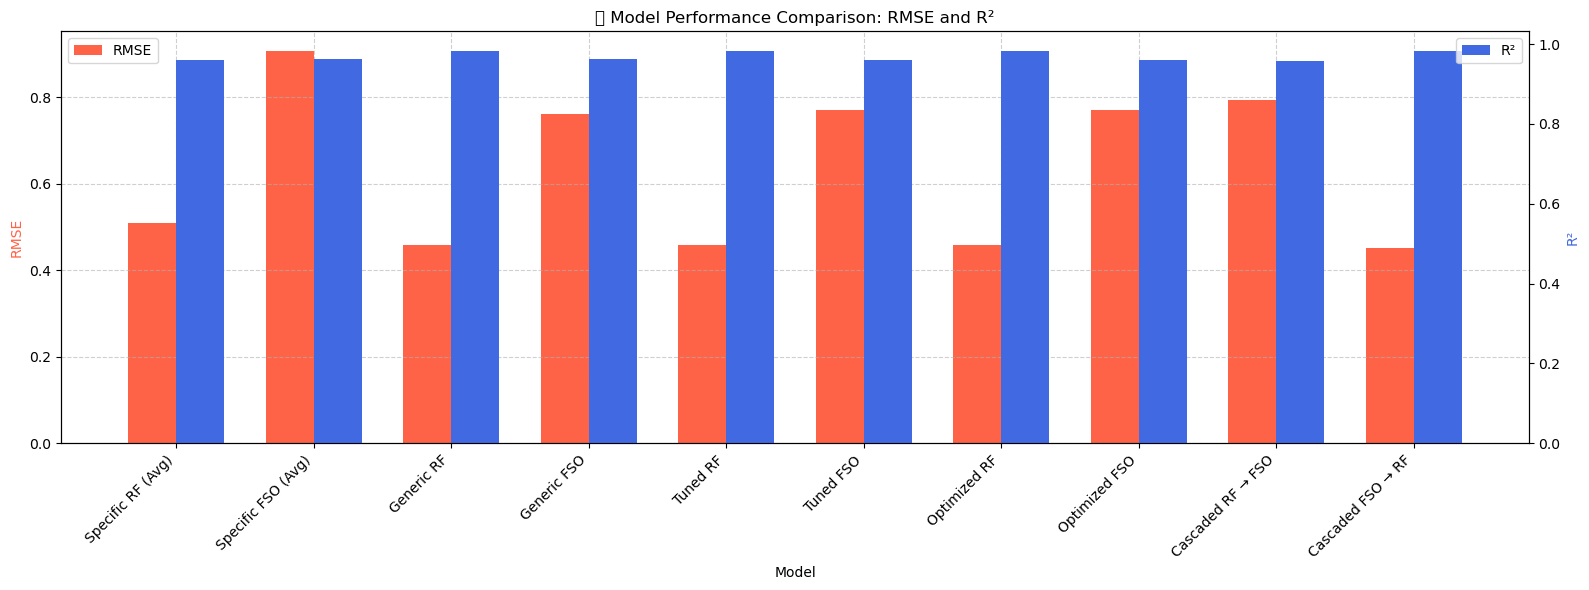

In [300]:

import matplotlib.pyplot as plt
import numpy as np

# Extract data
models = comparison_table['Model']
rmse_values = comparison_table['RMSE']
r2_values = comparison_table['R²']

x = np.arange(len(models))  
width = 0.35  

# Create subplots
fig, ax1 = plt.subplots(figsize=(16, 6))

# Plot RMSE bars
bar1 = ax1.bar(x - width/2, rmse_values, width, label='RMSE', color='tomato')

# Create second Y-axis for R²
ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, r2_values, width, label='R²', color='royalblue')

# Set labels and title
ax1.set_xlabel('Model')
ax1.set_ylabel('RMSE', color='tomato')
ax2.set_ylabel('R²', color='royalblue')
plt.title('📊 Model Performance Comparison: RMSE and R²')

# X-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right')

# Legends
ax1.legend([bar1], ['RMSE'], loc='upper left')
ax2.legend([bar2], ['R²'], loc='upper right')

# Grid
ax1.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


**Joint Probability Heatmaps of RF vs FSO Attenuation by SYNOP Code**

C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2648923002.py:48: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2648923002.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig(filename, dpi=300)
C:\Users\91984\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


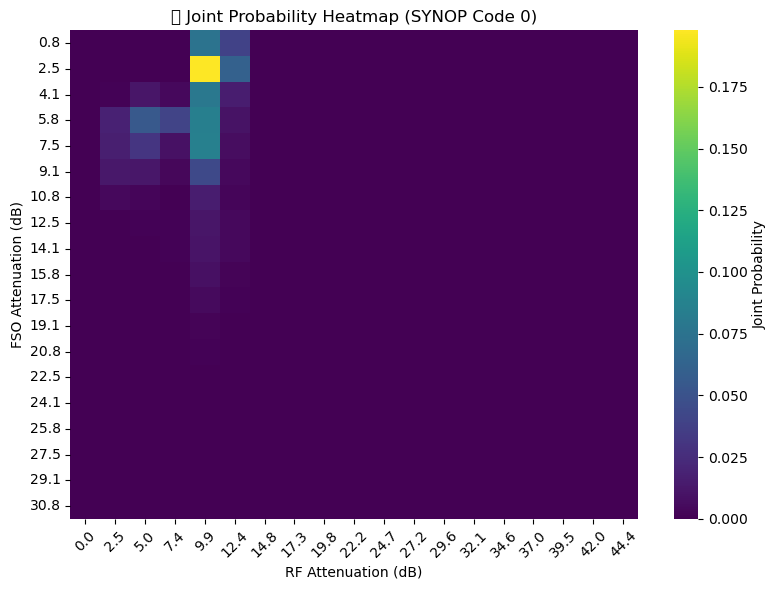

C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2648923002.py:48: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2648923002.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig(filename, dpi=300)
C:\Users\91984\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


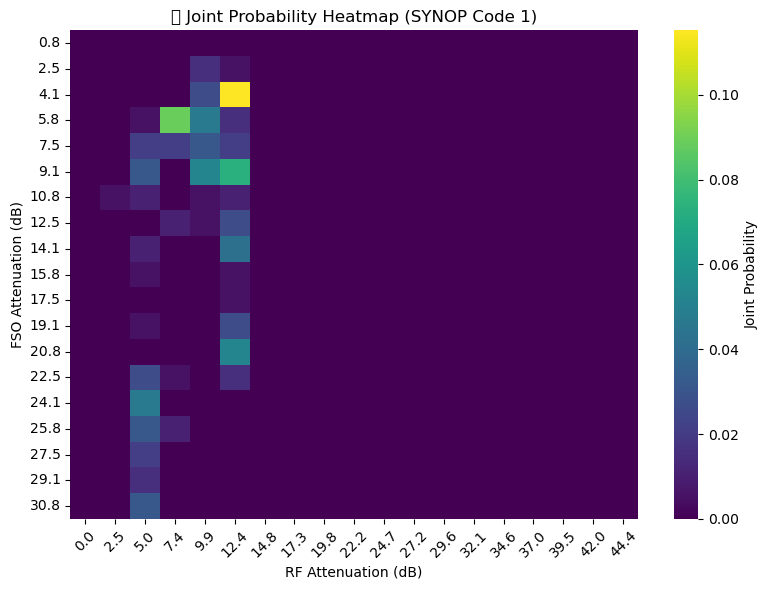

C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2648923002.py:48: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2648923002.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig(filename, dpi=300)
C:\Users\91984\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


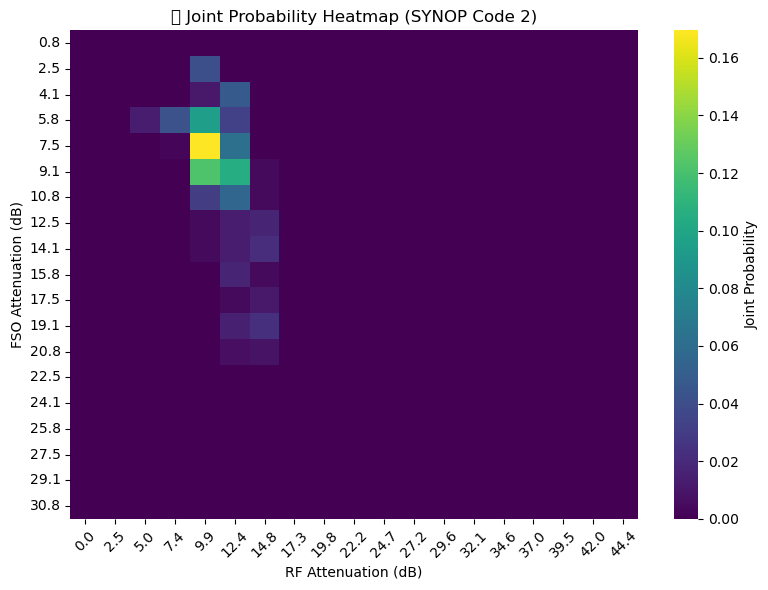

C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2648923002.py:48: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2648923002.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig(filename, dpi=300)
C:\Users\91984\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


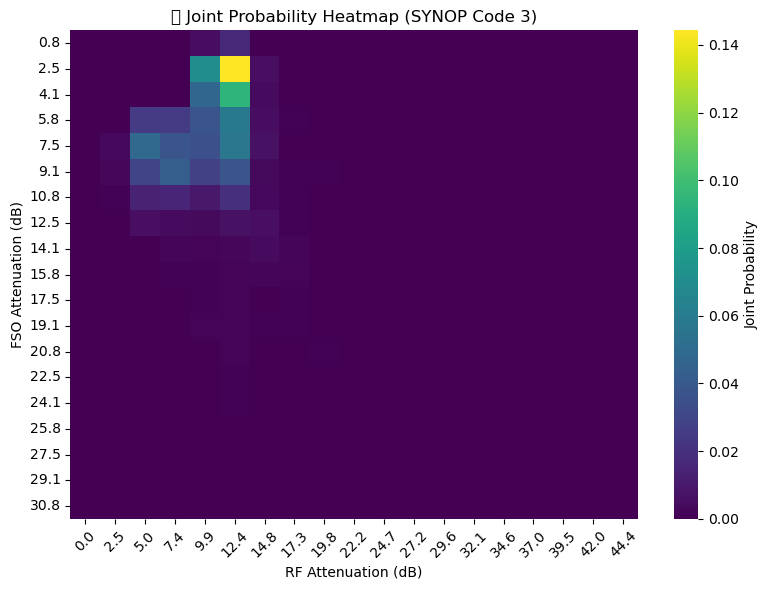

C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2648923002.py:48: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2648923002.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig(filename, dpi=300)
C:\Users\91984\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


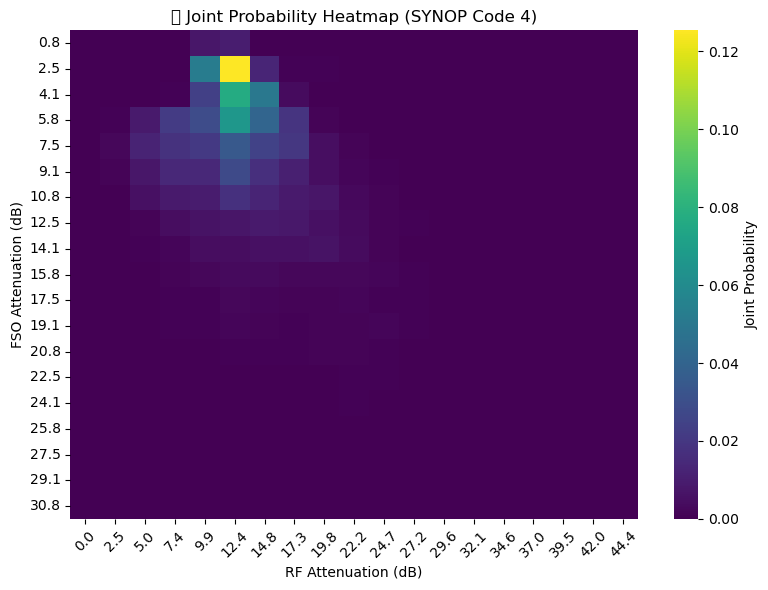

C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2648923002.py:48: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2648923002.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig(filename, dpi=300)
C:\Users\91984\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


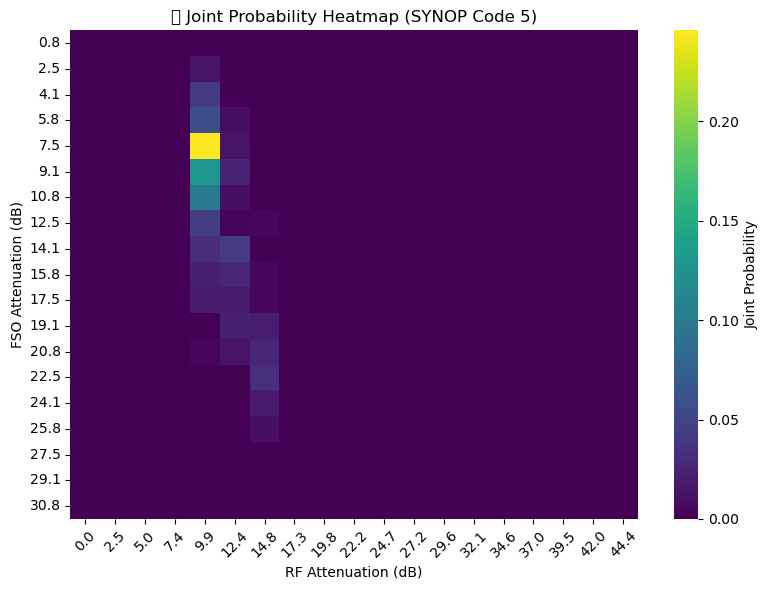

C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2648923002.py:48: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2648923002.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig(filename, dpi=300)
C:\Users\91984\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


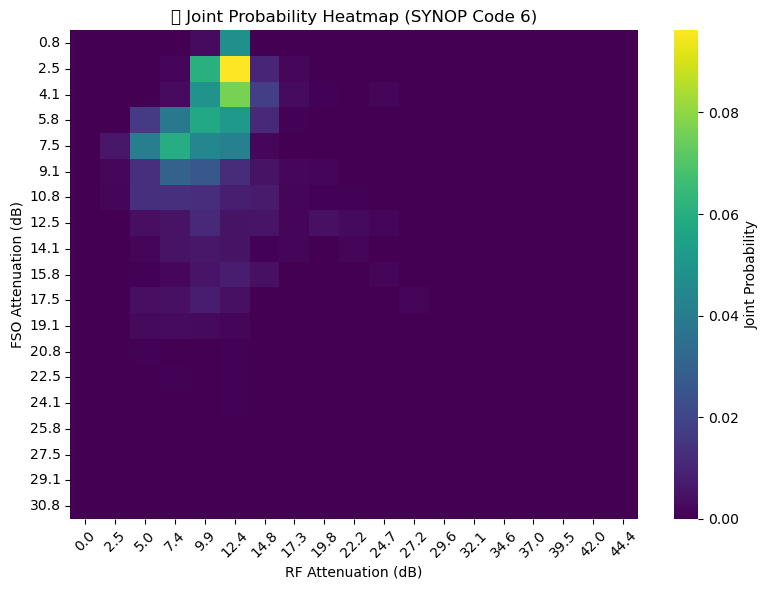

In [358]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create output directory if it doesn't exist
output_dir = "heatmaps"
os.makedirs(output_dir, exist_ok=True)

# Unique SYNOP codes
synop_codes = sorted(data['SYNOPCode'].unique())

# Define bins
num_bins = 20
rf_bins = np.linspace(data["RFL_Att"].min(), data["RFL_Att"].max(), num_bins)
fso_bins = np.linspace(data["FSO_Att"].min(), data["FSO_Att"].max(), num_bins)

# Loop through each SYNOP code
for synop in synop_codes:
    subset = data[data["SYNOPCode"] == synop]
    rf_values = subset["RFL_Att"]
    fso_values = subset["FSO_Att"]
    
    if len(rf_values) < 5 or len(fso_values) < 5:
        continue  

    joint_hist, x_edges, y_edges = np.histogram2d(
        rf_values, fso_values, bins=[rf_bins, fso_bins]
    )
    
    joint_prob = joint_hist / np.sum(joint_hist)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        joint_prob.T,
        cmap="viridis",
        cbar_kws={'label': 'Joint Probability'},
        xticklabels=np.round(x_edges[:-1], 1),
        yticklabels=np.round(y_edges[:-1], 1),
        annot=False
    )
    plt.xlabel("RF Attenuation (dB)")
    plt.ylabel("FSO Attenuation (dB)")
    plt.title(f"📊 Joint Probability Heatmap (SYNOP Code {synop})")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()

    # Save the figure
    filename = os.path.join(output_dir, f"heatmap_synop_{synop}.png")
    plt.savefig(filename, dpi=300)

    # Display the figure
    plt.show()


**Global Pearson and MI Before and After Cascading**

In [306]:
# For real RF-FSO
real_rf = y_test_rfl
real_fso = y_test_fso

# For predicted RF and FSO from cascaded models
pred_rf_from_fso = rf_cascaded_pred
pred_fso_from_rf = fso_cascaded_pred

from scipy.stats import pearsonr

# Global Pearson
pearson_real, _ = pearsonr(real_rf, real_fso)
pearson_pred_rf_fso, _ = pearsonr(rf_test_pred, fso_cascaded_pred)
pearson_pred_fso_rf, _ = pearsonr(fso_test_pred, rf_cascaded_pred)

print(f"📈 Real RF-FSO Pearson Correlation (Global): {pearson_real:.4f}")
print(f"📈 Predicted (RF→FSO) Pearson Correlation: {pearson_pred_rf_fso:.4f}")
print(f"📈 Predicted (FSO→RF) Pearson Correlation: {pearson_pred_fso_rf:.4f}")

# Global MI 
def compute_normalized_mi(x, y, bins=20):
    joint_hist, _, _ = np.histogram2d(x, y, bins=bins)
    joint_prob = joint_hist / np.sum(joint_hist)
    p_rf = np.sum(joint_prob, axis=1)
    p_fso = np.sum(joint_prob, axis=0)
    mutual_info = 0.0
    for i in range(bins):
        for j in range(bins):
            pxy = joint_prob[i, j]
            if pxy > 0:
                mutual_info += pxy * np.log2(pxy / (p_rf[i] * p_fso[j]))
    joint_entropy = -np.sum([p * np.log2(p) for p in joint_prob.flatten() if p > 0])
    return mutual_info / joint_entropy if joint_entropy > 0 else np.nan

# Global NMI
nmi_real = compute_normalized_mi(real_rf, real_fso)
nmi_pred_rf_fso = compute_normalized_mi(rf_test_pred, fso_cascaded_pred)
nmi_pred_fso_rf = compute_normalized_mi(fso_test_pred, rf_cascaded_pred)

print(f"🔵 Real RF-FSO NMI (Global): {nmi_real:.4f}")
print(f"🔵 Predicted (RF→FSO) NMI: {nmi_pred_rf_fso:.4f}")
print(f"🔵 Predicted (FSO→RF) NMI: {nmi_pred_fso_rf:.4f}")


📈 Real RF-FSO Pearson Correlation (Global): 0.0884
📈 Predicted (RF→FSO) Pearson Correlation: 0.0900
📈 Predicted (FSO→RF) Pearson Correlation: 0.0871
🔵 Real RF-FSO NMI (Global): 0.0584
🔵 Predicted (RF→FSO) NMI: 0.0654
🔵 Predicted (FSO→RF) NMI: 0.0662


C:\Users\91984\AppData\Local\Temp\ipykernel_2448\2754875760.py:33: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\91984\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


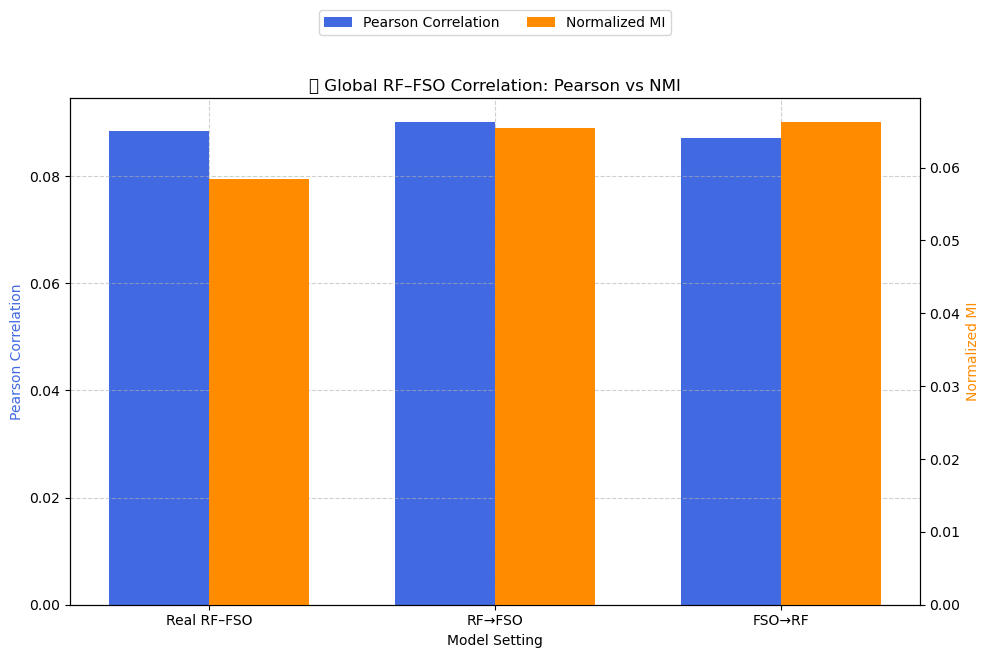

In [362]:
import matplotlib.pyplot as plt
import numpy as np

# Values from your results
pearson_values = [0.0884, 0.0900, 0.0871]
nmi_values = [0.0584, 0.0654, 0.0662]
labels = ['Real RF–FSO', 'RF→FSO', 'FSO→RF']

x = np.arange(len(labels))  
width = 0.35  

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Pearson bars
bar1 = ax1.bar(x - width/2, pearson_values, width, label='Pearson Correlation', color='royalblue')

# Create twin y-axis for NMI
ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, nmi_values, width, label='Normalized MI', color='darkorange')

# Labels and titles
ax1.set_ylabel('Pearson Correlation', color='royalblue')
ax2.set_ylabel('Normalized MI', color='darkorange')
ax1.set_xlabel('Model Setting')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
plt.title('📊 Global RF–FSO Correlation: Pearson vs NMI')

# Add legends
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2)
ax1.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


**Distribution of Prediction Errors for RF and FSO Attenuation**

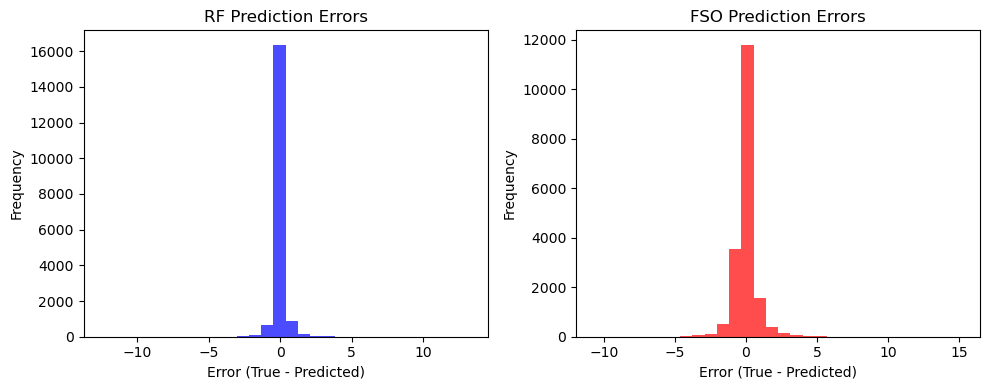

In [307]:
import matplotlib.pyplot as plt

# Calculate prediction errors
error_rf = y_test_rfl - rf_test_pred
error_fso = y_test_fso - fso_cascaded_pred

# Plot histograms
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(error_rf, bins=30, color='blue', alpha=0.7)
plt.title("RF Prediction Errors")
plt.xlabel("Error (True - Predicted)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(error_fso, bins=30, color='red', alpha=0.7)
plt.title("FSO Prediction Errors")
plt.xlabel("Error (True - Predicted)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
